In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [3]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [4]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [5]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


In [6]:
# ==============================================================================
# CELL 1.4: CREATE ID-TO-NAME MAPPING DICTIONARY
# ==============================================================================

# Crear un diccionario: {'P_25': 'roma_condesa_2', 'C_1': 'terminal_1_aicm', ...}
# .drop_duplicates() es vital para que no falle al crear el dict
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"✅ Mapping Dictionary Created. Size: {len(zone_map)} zones.")
# Prueba rápida
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1:  {zone_map.get('C_1', 'Not Found')}")

✅ Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1:  terminal_1_aicm


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


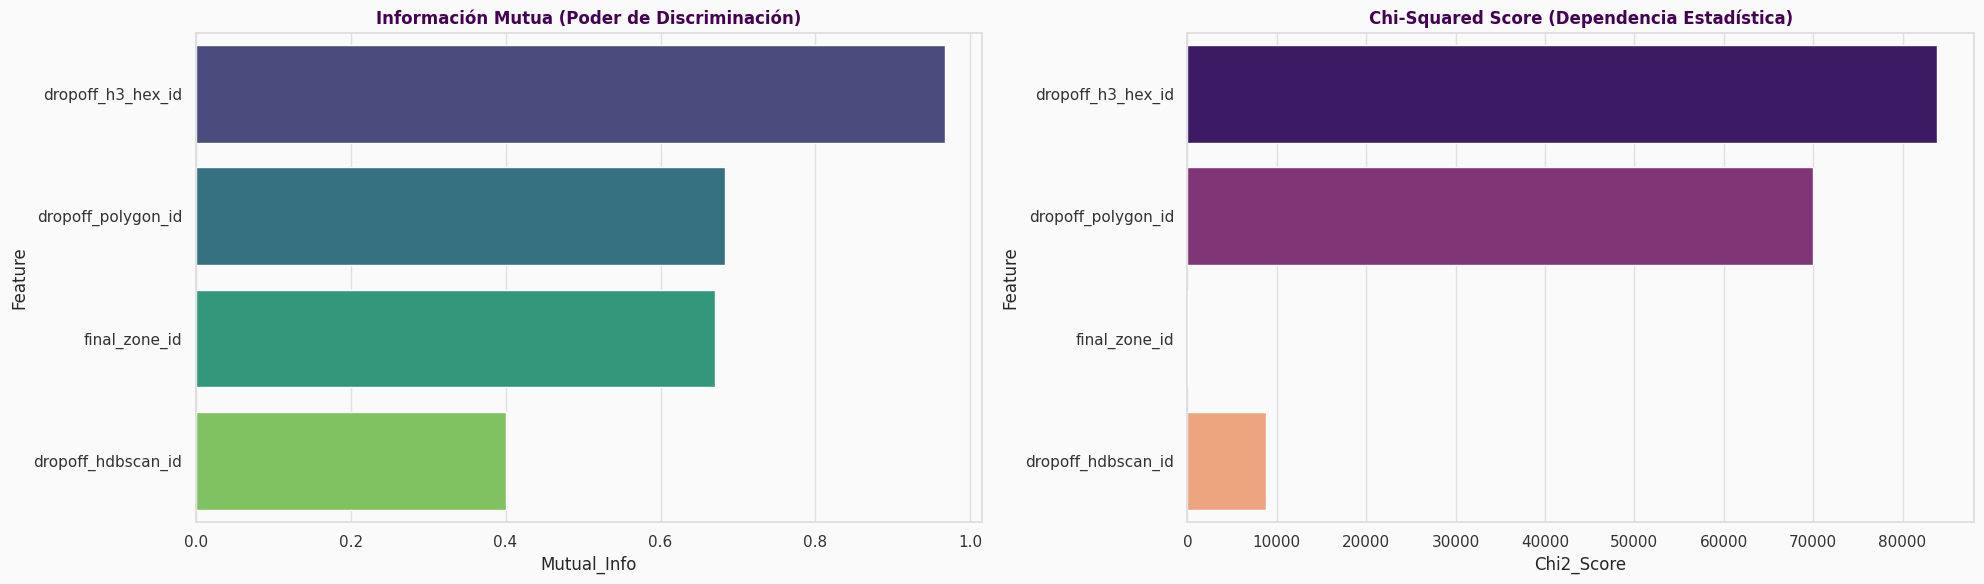

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [7]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [8]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
   *   `dropoff_polygon_id` (Original): **0.6838 bits**
   *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [9]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


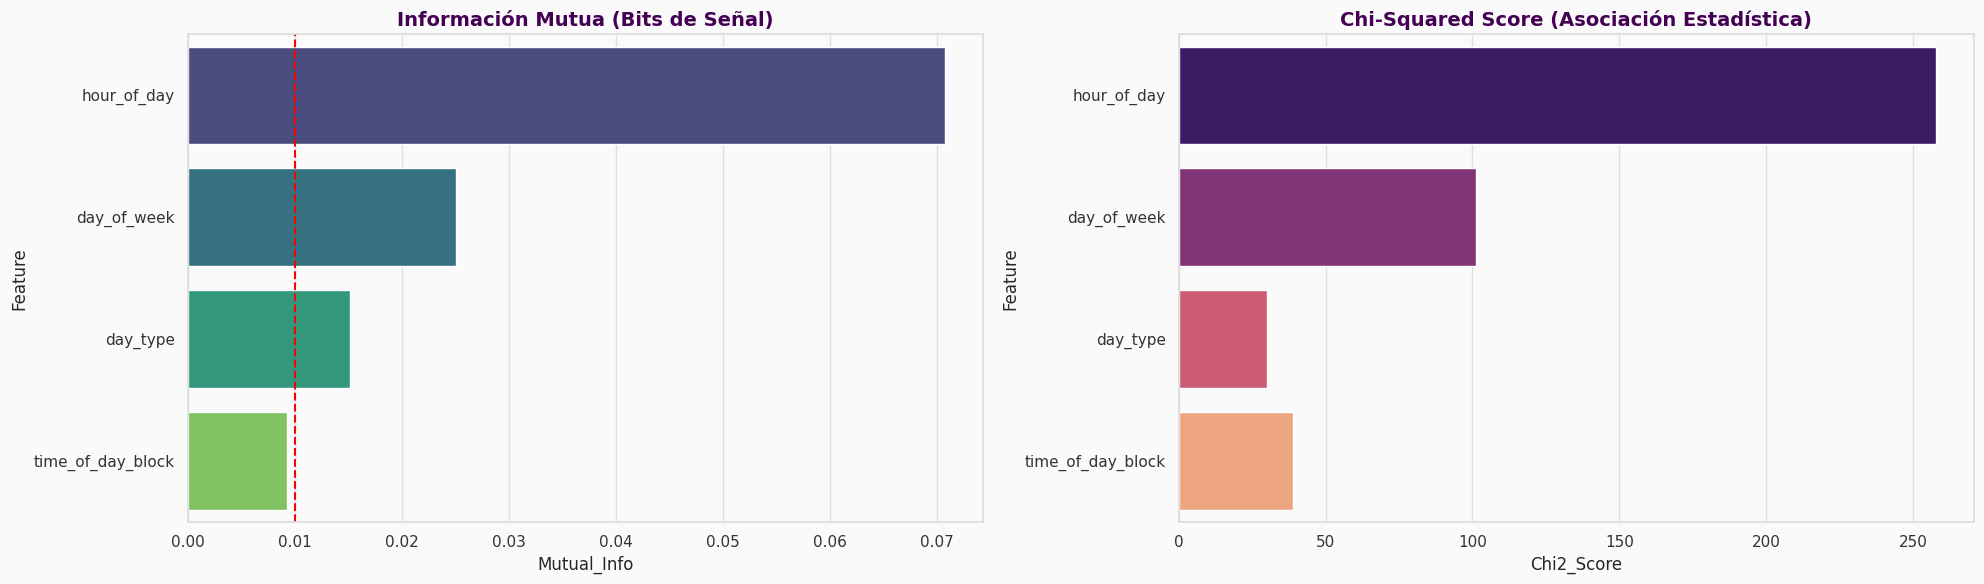

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [10]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 3 features in isolation...


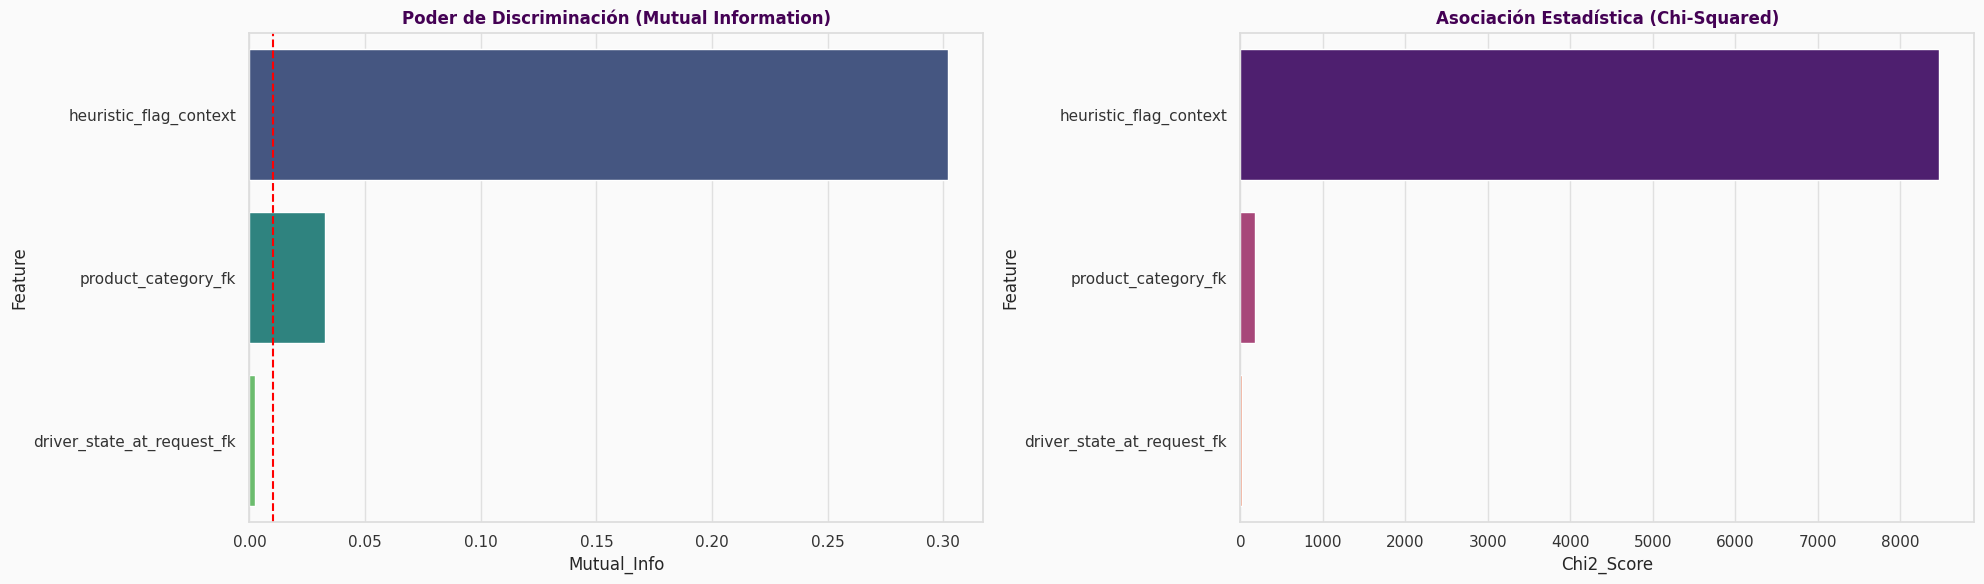

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,heuristic_flag_context,0.302027,8471.929880,0.000000e+00
1,product_category_fk,0.032699,182.354377,1.072798e-36
2,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.3020**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [11]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [12]:
# ==============================================================================
# CELL 1.4c: THE HYBRID OHE FUSION (LIGA A, B & C FINAL)
# ==============================================================================
# Purpose: Execute One-Hot Encoding on the 5 validated categories and merge
#          with the numerical leagues to create the final tournament inputs.
# ==============================================================================

print("⏳ Executing One-Hot Encoding on Categorical Survivors...")

# 1. LISTA BLANCA DE GANADORES (The Big 5)
winning_cats = [
    'final_zone_id',
    'heuristic_flag_context',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Preparamos la matriz categórica
X_cats_final = df_input[winning_cats].copy()
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

# 2. ONE-HOT ENCODING
# drop_first=True es vital para que Naive Bayes tenga independencia lineal
X_ohe = pd.get_dummies(X_cats_final, drop_first=True)

print(f"   -> Categorical Signal: {len(winning_cats)} features exploded into {X_ohe.shape[1]} binary columns.")

# 3. THE HYBRID FUSION (LIGAS A, B & C)

# LIGA A Hybrid: Wide PCA (21) + OHE
X_league_a_hybrid = pd.concat([X_wide_pca, X_ohe], axis=1)

# LIGA B Hybrid: Praetorian Raw (20) + OHE
X_league_b_hybrid = pd.concat([X_praetorian_final_raw, X_ohe], axis=1)

# LIGA C Hybrid: Praetorian PCA (12) + OHE
X_league_c_hybrid = pd.concat([X_praetorian_pca, X_ohe], axis=1)

# 4. FINAL DICTIONARY FOR THE TOURNAMENT
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
}

print(f"\n✅ HYBRID UNIVERSES FORGED AND READY:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---")

⏳ Executing One-Hot Encoding on Categorical Survivors...
   -> Categorical Signal: 5 features exploded into 103 binary columns.

✅ HYBRID UNIVERSES FORGED AND READY:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 122)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 123)
   -> LIGA_C_Praetorian_PCA_Hybrid   | Shape: (4760, 115)

--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---


In [13]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [14]:
# ==============================================================================
# CELL 1.5: TEMPORAL INDEXING (THE WALK-FORWARD ENGINE - v2.0)
# ==============================================================================
# Purpose: Map every observation to a specific "Week ID" based on the Architect's
#          Sacred Chronology and build the custom Cross-Validation iterator.
# ==============================================================================

print("⏳ Synchronizing Temporal Engine...")

# 1. DATETIME CONVERSION
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. THE SACRED CHRONOLOGY (Ratified Weeks)
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. ASSIGN WEEK IDs
df_input['week_id'] = 0 # Default placeholder

for wk, start, end in sacred_schedule:
    # Definimos el rango del día completo (00:00:00 a 23:59:59)
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 4. SANITY CHECK: Filtering out-of-bounds data
# Si alguna fila no entró en ninguna semana, la descartamos para no ensuciar el CV
df_input = df_input[df_input['week_id'] > 0].copy()
df_input = df_input.reset_index(drop=True) # RE-INDICE MANDATORIO

print("📅 FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 5. CONSTRUCT WALK-FORWARD FOLDS (The Custom CV Iterator)
custom_cv_folds = []

print("\n⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):")
for i in range(1, 6): # Iterations 1 to 5
    # Train: Accumulated Past (Weeks 1 to i)
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    # Test: The Immediate Future (Week i + 1)
    test_mask = (df_input['week_id'] == i + 1)

    # Get the row numbers (indices) for the model
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()

    custom_cv_folds.append((train_indices, test_indices))

    print(f"   -> Fold {i}: Train W[1-{i}] (n={len(train_indices)}) vs Test W{i+1} (n={len(test_indices)})")

print("\n✅ Temporal Engine Sincronized. Ready to test predictive resilience.")

⏳ Synchronizing Temporal Engine...
📅 FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64

⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):
   -> Fold 1: Train W[1-1] (n=952) vs Test W2 (n=856)
   -> Fold 2: Train W[1-2] (n=1808) vs Test W3 (n=364)
   -> Fold 3: Train W[1-3] (n=2172) vs Test W4 (n=599)
   -> Fold 4: Train W[1-4] (n=2771) vs Test W5 (n=1209)
   -> Fold 5: Train W[1-5] (n=3980) vs Test W6 (n=780)

✅ Temporal Engine Sincronized. Ready to test predictive resilience.


In [15]:
'''# ==============================================================================
# CELL 2 (CORREGIDA & JUSTA): XGBOOST TOURNAMENT (MANUAL LOOP CON PESOS)
# ==============================================================================
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import numpy as np
import re

print("⏳ Initiating XGBoost Battle Royale (AHORA CON PESOS BALANCEADOS)...")
print("⚔️ Rules: TimeSeriesSplit (4 folds) | Weights: Computed per fold\n")

# 1. PREPARACIÓN COMÚN
tscv = TimeSeriesSplit(n_splits=4)
le_xgb = LabelEncoder()
y_encoded = le_xgb.fit_transform(y.values.ravel() if hasattr(y, 'values') else y)

# 2. CARGA DE LIGAS
try:
    ligas = {
        "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
        "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
        "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
    }
except NameError:
    print("⚠️ Usando ligas_finales...")
    ligas = ligas_finales

results_manual = {}

# 3. EL BUCLE MANUAL (Para inyectar los pesos quirúrgicamente)
for name, X_league in ligas.items():
    print(f"🥊 Entrando al Ring: {name}...")

    # A. Limpieza de nombres (XGBoost Hygiene)
    X_clean = X_league.copy()
    if hasattr(X_clean, 'columns'):
        regex = re.compile(r"\[|\]|<", re.IGNORECASE)
        X_clean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_clean.columns]

    # B. Listas para guardar los scores de cada fold
    fold_f1, fold_prec, fold_rec = [], [], []

    # C. ITERACIÓN MANUAL SOBRE EL TIEMPO
    # Aquí es donde ocurre la magia que 'cross_validate' nos ocultaba
    fold_idx = 1
    for train_index, val_index in tscv.split(X_clean):

        # 1. Split Cronológico
        X_train_fold, X_val_fold = X_clean.iloc[train_index], X_clean.iloc[val_index]
        y_train_fold, y_val_fold = y_encoded[train_index], y_encoded[val_index]

        # 2. CÁLCULO DE PESOS (LA CORRECCIÓN QUE PEDISTE)
        # Calculamos los pesos SOLO basándonos en lo que el modelo "ve" (el pasado)
        # Esto equilibra las clases automáticamente.
        classes_in_fold = np.unique(y_train_fold)
        weights = compute_sample_weight(class_weight='balanced', y=y_train_fold)

        # 3. Configuración del Modelo
        model = xgb.XGBClassifier(
            objective='multi:softprob',
            eval_metric='mlogloss',
            n_estimators=50,
            max_depth=4,
            learning_rate=0.1,
            tree_method='hist',
            n_jobs=-1,
            random_state=42,
            use_label_encoder=False
        )

        # 4. Entrenamiento CON PESOS
        model.fit(X_train_fold, y_train_fold, sample_weight=weights)

        # 5. Predicción y Métricas
        y_pred = model.predict(X_val_fold)

        # Guardamos métricas (average='macro' es clave para el balance)
        fold_f1.append(f1_score(y_val_fold, y_pred, average='macro', zero_division=0))
        fold_prec.append(precision_score(y_val_fold, y_pred, average='macro', zero_division=0))
        fold_rec.append(recall_score(y_val_fold, y_pred, average='macro', zero_division=0))

        fold_idx += 1

    # D. Promedios del Torneo
    results_manual[name] = {
        'F1_Macro (Mean)': np.mean(fold_f1),
        'Stability (Std Dev)': np.std(fold_f1),
        'Precision (Mean)': np.mean(fold_prec),
        'Recall (Mean)': np.mean(fold_rec)
    }

# 4. EL LEADERBOARD REALISTA
df_leaderboard_xgb = pd.DataFrame(results_manual).T.sort_values(by='F1_Macro (Mean)', ascending=False)

print("\n" + "="*70)
print("🏆 FINAL SCORECARD: XGBOOST (WEIGHTED & FAIR)")
print("="*70)
display(df_leaderboard_xgb.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

# Selección del Ganador
if not df_leaderboard_xgb.empty:
    winner_name_xgb = df_leaderboard_xgb.index[0]
    X_multi_winner = ligas[winner_name_xgb]

    # Limpieza final para la siguiente etapa
    if hasattr(X_multi_winner, 'columns'):
        regex = re.compile(r"\[|\]|<", re.IGNORECASE)
        X_multi_winner.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_multi_winner.columns]

    print(f"\n🌟 EL GANADOR ES: {winner_name_xgb}")
    print(f"✅ Variable 'X_multi_winner' lista (Score Justo y Balanceado).")'''

<>:41: SyntaxWarning: invalid escape sequence '\['
<>:41: SyntaxWarning: invalid escape sequence '\['
/tmp/ipython-input-2355471372.py:41: SyntaxWarning: invalid escape sequence '\['
  regex = re.compile(r"\[|\]|<", re.IGNORECASE)


'# ==============================================================================\n# CELL 2 (CORREGIDA & JUSTA): XGBOOST TOURNAMENT (MANUAL LOOP CON PESOS)\n# ==============================================================================\nimport xgboost as xgb\nfrom sklearn.model_selection import TimeSeriesSplit\nfrom sklearn.metrics import f1_score, precision_score, recall_score\nfrom sklearn.preprocessing import LabelEncoder\nfrom sklearn.utils.class_weight import compute_sample_weight\nimport pandas as pd\nimport numpy as np\nimport re\n\nprint("⏳ Initiating XGBoost Battle Royale (AHORA CON PESOS BALANCEADOS)...")\nprint("⚔️ Rules: TimeSeriesSplit (4 folds) | Weights: Computed per fold\n")\n\n# 1. PREPARACIÓN COMÚN\ntscv = TimeSeriesSplit(n_splits=4)\nle_xgb = LabelEncoder()\ny_encoded = le_xgb.fit_transform(y.values.ravel() if hasattr(y, \'values\') else y)\n\n# 2. CARGA DE LIGAS\ntry:\n    ligas = {\n        "LIGA_A_Wide_Hybrid": X_league_a_hybrid,\n        "LIGA_B_Praetorian_Raw_

In [16]:
'''# ==============================================================================
# CELL 2: XGBOOST EXPERIMENT RUNNER (CACHEABLE)
# ==============================================================================
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import numpy as np
import re
import joblib
import os

# --- 1. INTERACTIVE SETUP ---
# This creates a text box for you to name this specific experiment
iter_tag = input("🏷️ Enter Iteration Name (e.g., 'n50_depth3' or 'iter1'): ").strip()
if not iter_tag: raise ValueError("❌ You must provide a tag name!")

# --- 2. HYPERPARAMETERS CONTROL PANEL ---
# CHANGE THESE VALUES MANUALLY FOR YOUR A/B TESTING
xgb_params = {
    'n_estimators': 30,         # <--- Change this
    'max_depth': 4,             # <--- Change this
    'learning_rate': 0.1,       # <--- Change this
    'min_child_weight': 1,      # <--- Change this
    'gamma': 0,                 # <--- Change this
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'n_jobs': -1,
    'random_state': 42,
    'use_label_encoder': False
}

print(f"\n⏳ Initiating Experiment: '{iter_tag}'")
print(f"⚙️ Params: {xgb_params}")

# --- 3. PREPARATION ---
tscv = TimeSeriesSplit(n_splits=4)
le_xgb = LabelEncoder()
y_encoded = le_xgb.fit_transform(y.values.ravel() if hasattr(y, 'values') else y)

try:
    ligas = {
        "LIGA_A_Wide": X_league_a_hybrid,
        "LIGA_B_Raw": X_league_b_hybrid,
        "LIGA_C_PCA": X_league_c_hybrid
    }
except NameError:
    print("⚠️ Usando ligas_finales...")
    ligas = ligas_finales

results_manual = {}

# --- 4. THE MANUAL LOOP ---
for name, X_league in ligas.items():
    print(f"🥊 Training on: {name}...")

    # A. Hygiene
    X_clean = X_league.copy()
    if hasattr(X_clean, 'columns'):
        regex = re.compile(r"\[|\]|<", re.IGNORECASE)
        X_clean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_clean.columns]

    # B. Fold Storage
    fold_f1, fold_prec, fold_rec = [], [], []

    # C. TimeSeries Split
    for train_index, val_index in tscv.split(X_clean):
        X_train_fold, X_val_fold = X_clean.iloc[train_index], X_clean.iloc[val_index]
        y_train_fold, y_val_fold = y_encoded[train_index], y_encoded[val_index]

        # Weights per fold
        weights = compute_sample_weight(class_weight='balanced', y=y_train_fold)

        # Dynamic Model Initialization (Unpacking params)
        model = xgb.XGBClassifier(**xgb_params)

        # Train
        model.fit(X_train_fold, y_train_fold, sample_weight=weights)

        # Predict
        y_pred = model.predict(X_val_fold)

        # Score
        fold_f1.append(f1_score(y_val_fold, y_pred, average='macro', zero_division=0))
        fold_prec.append(precision_score(y_val_fold, y_pred, average='macro', zero_division=0))
        fold_rec.append(recall_score(y_val_fold, y_pred, average='macro', zero_division=0))

    # D. Aggregation
    results_manual[name] = {
        'F1_Macro': np.mean(fold_f1),
        'Stability (Std)': np.std(fold_f1),
        'Precision': np.mean(fold_prec),
        'Recall': np.mean(fold_rec)
    }

# --- 5. RESULTS & CACHING ---
df_leaderboard = pd.DataFrame(results_manual).T.sort_values(by='F1_Macro', ascending=False)

# Define Cache Path (Adjust if needed)
CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/' # Make sure this exists
if not os.path.exists(CACHE_PATH): os.makedirs(CACHE_PATH)

filename = f"XGB_{iter_tag}.joblib"
full_path = os.path.join(CACHE_PATH, filename)

# The Payload: We save the config AND the result
experiment_data = {
    'tag': iter_tag,
    'params': xgb_params,
    'leaderboard': df_leaderboard,
    'winner_name': df_leaderboard.index[0],
    'winner_score': df_leaderboard.iloc[0]['F1_Macro']
}

joblib.dump(experiment_data, full_path)

print("\n" + "="*60)
print(f"💾 EXPERIMENT SAVED: {filename}")
print("="*60)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro']))'''

<>:65: SyntaxWarning: invalid escape sequence '\['
<>:65: SyntaxWarning: invalid escape sequence '\['
/tmp/ipython-input-1769062073.py:65: SyntaxWarning: invalid escape sequence '\['
  regex = re.compile(r"\[|\]|<", re.IGNORECASE)


'# ==============================================================================\n# CELL 2: XGBOOST EXPERIMENT RUNNER (CACHEABLE)\n# ==============================================================================\nimport xgboost as xgb\nfrom sklearn.model_selection import TimeSeriesSplit\nfrom sklearn.metrics import f1_score, precision_score, recall_score\nfrom sklearn.preprocessing import LabelEncoder\nfrom sklearn.utils.class_weight import compute_sample_weight\nimport pandas as pd\nimport numpy as np\nimport re\nimport joblib\nimport os\n\n# --- 1. INTERACTIVE SETUP ---\n# This creates a text box for you to name this specific experiment\niter_tag = input("🏷️ Enter Iteration Name (e.g., \'n50_depth3\' or \'iter1\'): ").strip()\nif not iter_tag: raise ValueError("❌ You must provide a tag name!")\n\n# --- 2. HYPERPARAMETERS CONTROL PANEL ---\n# CHANGE THESE VALUES MANUALLY FOR YOUR A/B TESTING\nxgb_params = {\n    \'n_estimators\': 30,         # <--- Change this\n    \'max_depth\': 4, 

In [17]:
# ==============================================================================
# CELL 2: XGBOOST EXPERIMENT RUNNER (FOCUSED ON LIGA B)
# ==============================================================================
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import numpy as np
import re
import joblib
import os

# --- 1. INTERACTIVE SETUP ---
# This creates a text box for you to name this specific experiment
iter_tag = input("🏷️ Enter Iteration Name (e.g., 'n50_depth3' or 'iter1'): ").strip()
if not iter_tag: raise ValueError("❌ You must provide a tag name!")

# --- 2. HYPERPARAMETERS CONTROL PANEL ---
# CHANGE THESE VALUES MANUALLY FOR YOUR A/B TESTING
xgb_params = {
    'n_estimators': 50,         # <--- Change this
    'max_depth': 4,             # <--- Change this
    'learning_rate': 0.05,       # <--- Change this
    'min_child_weight': 1.75,      # <--- Change this
    'gamma': 1.25,                 # <--- Change this
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'n_jobs': -1,
    'random_state': 42,
    'use_label_encoder': False
}

print(f"\n⏳ Initiating Experiment: '{iter_tag}'")
print(f"⚙️ Params: {xgb_params}")

# --- 3. PREPARATION (LOCKED ON LIGA B) ---
tscv = TimeSeriesSplit(n_splits=4)
le_xgb = LabelEncoder()
y_encoded = le_xgb.fit_transform(y.values.ravel() if hasattr(y, 'values') else y)

print("🎯 LOCKING TARGET: LIGA B (The Landslide Winner)...")

# Logic to safely grab Liga B whether it's a standalone var or inside the dict
try:
    if 'X_league_b_hybrid' in locals():
        X_target = X_league_b_hybrid
    else:
        X_target = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid']
except NameError:
    raise ValueError("❌ Critical Error: LIGA B data not found in memory.")

# We keep the dictionary structure so the loop downstream works identically
ligas = {
    "LIGA_B_Praetorian_Raw_Hybrid": X_target
}

results_manual = {}

# --- 4. THE MANUAL LOOP (Single Iteration) ---
for name, X_league in ligas.items():
    print(f"🥊 Training on: {name}...")

    # A. Hygiene
    X_clean = X_league.copy()
    if hasattr(X_clean, 'columns'):
        regex = re.compile(r"\[|\]|<", re.IGNORECASE)
        X_clean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_clean.columns]

    # B. Fold Storage
    fold_f1, fold_prec, fold_rec = [], [], []

    # C. TimeSeries Split
    for train_index, val_index in tscv.split(X_clean):
        X_train_fold, X_val_fold = X_clean.iloc[train_index], X_clean.iloc[val_index]
        y_train_fold, y_val_fold = y_encoded[train_index], y_encoded[val_index]

        # Weights per fold
        weights = compute_sample_weight(class_weight='balanced', y=y_train_fold)

        # Dynamic Model Initialization (Unpacking params)
        model = xgb.XGBClassifier(**xgb_params)

        # Train
        model.fit(X_train_fold, y_train_fold, sample_weight=weights)

        # Predict
        y_pred = model.predict(X_val_fold)

        # Score
        fold_f1.append(f1_score(y_val_fold, y_pred, average='macro', zero_division=0))
        fold_prec.append(precision_score(y_val_fold, y_pred, average='macro', zero_division=0))
        fold_rec.append(recall_score(y_val_fold, y_pred, average='macro', zero_division=0))

    # D. Aggregation
    results_manual[name] = {
        'F1_Macro': np.mean(fold_f1),
        'Stability (Std)': np.std(fold_f1),
        'Precision': np.mean(fold_prec),
        'Recall': np.mean(fold_rec)
    }

# --- 5. RESULTS & CACHING ---
df_leaderboard = pd.DataFrame(results_manual).T.sort_values(by='F1_Macro', ascending=False)

# Define Cache Path (Matches your provided path)
CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/'
if not os.path.exists(CACHE_PATH): os.makedirs(CACHE_PATH)

filename = f"XGB_{iter_tag}.joblib"
full_path = os.path.join(CACHE_PATH, filename)

# The Payload: We save the config AND the result
experiment_data = {
    'tag': iter_tag,
    'params': xgb_params,
    'leaderboard': df_leaderboard,
    'winner_name': df_leaderboard.index[0],
    'winner_score': df_leaderboard.iloc[0]['F1_Macro']
}

joblib.dump(experiment_data, full_path)

print("\n" + "="*60)
print(f"💾 EXPERIMENT SAVED: {filename}")
print("="*60)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro']))

KeyboardInterrupt: Interrupted by user

In [18]:
# ==============================================================================
# CELL 2.1: EXPERIMENT COMPARATOR (LAB NOTEBOOK)
# ==============================================================================
import joblib
import pandas as pd
import glob
import os

# 1. SCAN FOR FILES
CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/'
search_pattern = os.path.join(CACHE_PATH, "XGB_*.joblib")
files = glob.glob(search_pattern)

print(f"📂 Found {len(files)} experiment files in cache.\n")

lab_notebook = []

# 2. LOAD AND EXTRACT
for file in files:
    try:
        data = joblib.load(file)

        # Flatten the data for a nice table
        entry = {
            'Tag': data['tag'],
            'Winner_League': data['winner_name'],
            'F1_Score': data['winner_score'],
            # Extract key params for comparison
            'n_est': data['params']['n_estimators'],
            'depth': data['params']['max_depth'],
            'lr': data['params']['learning_rate'],
            'min_child': data['params']['min_child_weight'],
            'gamma': data['params']['gamma']
        }
        lab_notebook.append(entry)
    except Exception as e:
        print(f"⚠️ Error loading {os.path.basename(file)}: {e}")

# 3. DISPLAY COMPARISON
if lab_notebook:
    df_lab = pd.DataFrame(lab_notebook).sort_values(by='F1_Score', ascending=False)

    print("🏆 EXPERIMENT LEADERBOARD")
    # Styling to highlight the best score
    display(df_lab.style.background_gradient(cmap='plasma', subset=['F1_Score']))
else:
    print("❌ No experiments found yet. Run Cell 2!")

📂 Found 38 experiment files in cache.

🏆 EXPERIMENT LEADERBOARD


,Tag,Winner_League,F1_Score,n_est,depth,lr,min_child,gamma
37,iter36,LIGA_B_Praetorian_Raw_Hybrid,0.577060,50,4,0.050000,1.750000,1.250000
35,iter34,LIGA_B_Praetorian_Raw_Hybrid,0.576287,50,4,0.050000,2.000000,1.250000
29,iter28,LIGA_B_Praetorian_Raw_Hybrid,0.573866,50,4,0.100000,2.000000,1.250000
34,iter33,LIGA_B_Praetorian_Raw_Hybrid,0.573113,50,3,0.100000,2.000000,1.250000
36,iter35,LIGA_B_Praetorian_Raw_Hybrid,0.569641,50,4,0.050000,2.250000,1.250000
28,iter_26_subcol_9,LIGA_B_Praetorian_Raw_Hybrid,0.568615,30,4,0.100000,2.000000,1.250000
32,iter31,LIGA_B_Praetorian_Raw_Hybrid,0.567594,50,4,0.100000,2.000000,1.500000
26,iter15_g1_25,LIGA_B_Praetorian_Raw_Hybrid,0.566630,30,4,0.100000,2.000000,1.250000
24,iter23_g1,LIGA_B_Praetorian_Raw_Hybrid,0.566089,30,4,0.100000,2.000000,1.000000
20,iter19-ch2,LIGA_B_Praetorian_Raw_Hybrid,0.564620,30,4,0.100000,2.000000,0.000000


In [19]:
# ==============================================================================
# CELL 2.2: PROMOTE CANDIDATE TO CHAMPION (LOAD & TRAIN)
# ==============================================================================
import xgboost as xgb
import joblib
import os
import re
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# 1. SELECCIÓN DEL CANDIDATO
# Escribe aquí el nombre EXACTO del tag que quieres "ascender"
target_tag = input("🏆 Enter the Tag of the Winner to promote (e.g., 'iter_26'): ").strip()

CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/' # Misma ruta que Cell 2
filename = f"XGB_{target_tag}.joblib"
full_path = os.path.join(CACHE_PATH, filename)

if not os.path.exists(full_path):
    raise ValueError(f"🔴 File not found: {filename}. Check the name or run Cell 2 first.")

# 2. CARGA DE CONFIGURACIÓN
print(f"⏳ Loading configuration from {filename}...")
experiment_data = joblib.load(full_path)

winner_params = experiment_data['params']
winner_league_name = experiment_data['winner_name']
best_cv_score = experiment_data['winner_score']

print(f"✅ Loaded Params: {winner_params}")
print(f"✅ Winner League: {winner_league_name}")
print(f"✅ Expected F1 Score (CV): {best_cv_score:.4f}")

# 3. PREPARACIÓN DE DATOS (RECONSTRUCCIÓN DEL TRAIN SET)
print("⚙️ Rebuilding Training Set (Weeks 1-5)...")

# A. Seleccionar la Liga Correcta
if winner_league_name in ligas_finales:
    X_full = ligas_finales[winner_league_name].copy()
else:
    raise ValueError(f"🔴 League '{winner_league_name}' not found in ligas_finales.")

# B. Limpieza de Nombres (Regex)
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_full.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_full.columns]

# C. Corte Temporal (Train vs Test)
# Usamos 'week_id' de df_input para asegurar que solo entrenamos con el pasado
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 'week_id' missing. Run Cell 1.5 first.")

CUTOFF_WEEK = 5
train_mask = df_input['week_id'] <= CUTOFF_WEEK
X_train_final = X_full[train_mask]
y_train_final = y[train_mask] # Usamos el y global original

# D. Codificación de Y (para XGBoost)
le_xgb = LabelEncoder()
y_train_enc = le_xgb.fit_transform(y_train_final.values.ravel() if hasattr(y_train_final, 'values') else y_train_final)

# E. Pesos Balanceados
print("⚖️ Computing Class Weights...")
weights_final = compute_sample_weight(class_weight='balanced', y=y_train_enc)

# 4. ENTRENAMIENTO FINAL (PROMOCIÓN)
print(f"🚀 Training Champion Model on {len(X_train_final)} rows...")

model_champion_xgb = xgb.XGBClassifier(**winner_params)
model_champion_xgb.fit(
    X_train_final,
    y_train_enc,
    sample_weight=weights_final
)

print("\n" + "="*60)
print(f"🌟 MODEL PROMOTED: model_champion_xgb")
print("="*60)
print("Ready for Final Exam (Cell 5.1).")

🏆 Enter the Tag of the Winner to promote (e.g., 'iter_26'): iter36
⏳ Loading configuration from XGB_iter36.joblib...
✅ Loaded Params: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1.75, 'gamma': 1.25, 'subsample': 0.9, 'colsample_bytree': 0.9, 'objective': 'multi:softprob', 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'n_jobs': -1, 'random_state': 42, 'use_label_encoder': False}
✅ Winner League: LIGA_B_Praetorian_Raw_Hybrid
✅ Expected F1 Score (CV): 0.5771
⚙️ Rebuilding Training Set (Weeks 1-5)...
⚖️ Computing Class Weights...
🚀 Training Champion Model on 3980 rows...

🌟 MODEL PROMOTED: model_champion_xgb
Ready for Final Exam (Cell 5.1).


In [20]:
# ==============================================================================
# CELL 1.6 (FIXED): SANITY CHECK - INTEGRIDAD DE LA ESTRATIFICACIÓN TEMPORAL
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("⏳ Executing Final Stratification Integrity Check (Multiclass)...")

# --- 0. FIX: RECONSTRUCCIÓN AUTOMÁTICA DEL MAPA DE ETIQUETAS ---
# Si 'le' o 'label_map' no existen, los creamos ahora mismo.
if 'le' not in locals() or 'label_map' not in locals():
    print("⚠️ Reconstruyendo mapa de etiquetas (LabelEncoder)...")

    # Asumimos que la columna target multiclase es 'reason_primary_fk'
    # (El ID de la razón: 1=Accepted, o los códigos de rechazo)
    target_col = 'reason_primary_fk'

    # Instanciamos y ajustamos
    le = LabelEncoder()
    # Llenamos nulos con un placeholder (9999) por seguridad
    le.fit(df_input[target_col].fillna(9999))

    # Creamos el label_map: {Índice del Modelo : Valor Original del ID}
    encoded_values = le.transform(le.classes_)
    label_map = dict(zip(encoded_values, le.classes_))

    # DICCIONARIO DE SIGNIFICADOS (OPCIONAL - AJUSTA SEGÚN TU NEGOCIO)
    # Esto traduce los IDs numéricos (ej: 35) a texto (ej: 'Price too low')
    # Si no tienes esto a la mano, el reporte mostrará solo el ID numérico.
    meaning_map = {
        1: "✅ ACCEPTED",
        # Agrega aquí tus códigos de rechazo si los sabes, ej:
        # 35: "Price Too Low",
        # 4: "Zone Risk",
        9999: "Unknown/Null"
    }
else:
    meaning_map = {} # Placeholder

# -------------------------------------------------------------------

# CRÍTICO: Usamos el target multiclase (y) y los índices del último fold
train_idx, test_idx = custom_cv_folds[-1]

# Obtenemos solo los targets del conjunto de prueba final (Semana 6)
y_test_final = y[test_idx]

# 1. Conteo de Frecuencias
total_test = len(y_test_final)
class_counts = pd.Series(y_test_final).value_counts().sort_index()

# 2. Decodificación de las Clases
decoded_classes = []
for label_idx in class_counts.index:
    # A) Recuperamos el ID original (ej: 1, 35, 4...)
    original_id = label_map.get(label_idx, f"Err-{label_idx}")

    # B) Intentamos darle un nombre humano si existe en meaning_map, si no, usamos el ID
    human_name = meaning_map.get(original_id, f"Reason ID: {original_id}")

    decoded_classes.append(human_name)

# 3. Creación del Reporte Detallado
report_df = pd.DataFrame({
    'Class Name': decoded_classes,
    'Model Label': class_counts.index, # Qué número ve el modelo internamente
    'Count': class_counts.values,
    'Proportion (%)': (class_counts.values / total_test) * 100
}).sort_values(by='Count', ascending=False)

display(Markdown(f"""
### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

* **Total Observaciones de Prueba (N):** `{total_test}`
* **Protocolo:** Walk-Forward (Semana 6).

#### **Resultado de la Distribución de Clases:**
"""))

# Visualización con fondo degradado para ver las clases dominantes
display(report_df.style.background_gradient(cmap='magma', subset=['Proportion (%)']))

# 4. Verificación Estratégica
if total_test > 500:
    print("\n✅ INTEGRIDAD: La masa crítica es suficiente (>500) para una validación robusta.")
else:
    print("\n⚠️ ALERTA: Muestra de prueba pequeña. El modelo será sensible a outliers.")

⏳ Executing Final Stratification Integrity Check (Multiclass)...
⚠️ Reconstruyendo mapa de etiquetas (LabelEncoder)...



### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

* **Total Observaciones de Prueba (N):** `780`
* **Protocolo:** Walk-Forward (Semana 6).

#### **Resultado de la Distribución de Clases:**


,Class Name,Model Label,Count,Proportion (%)
0,✅ ACCEPTED,0,391,50.128205
2,Reason ID: 3.0,2,128,16.410256
6,Unknown/Null,6,67,8.589744
4,Reason ID: 5.0,4,56,7.179487
3,Reason ID: 4.0,3,56,7.179487
1,Reason ID: 2.0,1,41,5.256410
5,Reason ID: 6.0,5,41,5.256410



✅ INTEGRIDAD: La masa crítica es suficiente (>500) para una validación robusta.


### A partir de aqui se ajustan y optimizan hiperparametros

In [21]:
# ==============================================================================
# CELL 3 (FIXED): PURGE, SPLIT, AND ISOLATION (CHRONOLOGICAL LOCKDOWN)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...")

# 1. AISLAMIENTO DE LA LIGA GANADORA (LIGA B)
# Usamos 'copy()' para asegurar que es un objeto independiente en memoria
X_final = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()

# 2. DEFINICIÓN DEL CORTE TEMPORAL (Semana 6 es Test)
# Requerimos 'week_id' del df_input original para hacer el corte
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 ERROR CRÍTICO: No se encuentra 'week_id'. Corre la Celda 1.5 primero.")

CUTOFF_WEEK = 5 # Entrenamos con Semanas 1, 2, 3, 4, 5. Testeamos con 6.

# Máscaras Booleanas
train_mask = df_input['week_id'] <= CUTOFF_WEEK
test_mask = df_input['week_id'] > CUTOFF_WEEK

# 3. SPLIT SAGRADO (CRONOLÓGICO)
# No usamos train_test_split aleatorio. Usamos el tiempo.
X_train = X_final[train_mask]
X_test  = X_final[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# 4. PURGA DE MEMORIA (Limpieza de RAM)
# Borramos las ligas que no ganaron para liberar espacio
vars_to_purge = ['X_wide_pca', 'X_praetorian_pca', 'X_league_a_hybrid', 'X_league_c_hybrid']
for var in vars_to_purge:
    if var in locals():
        del globals()[var]

print("✅ Ligas perdedoras purgadas. RAM liberada.")

# 5. REPORTE DE INTEGRIDAD
print(f"\n✅ Final Dataset Locked (Liga B, Raw Hybrid).")
print(f"   -> Estrategia: Walk-Forward (Train: W1-{CUTOFF_WEEK} | Test: W{CUTOFF_WEEK+1})")
print(f"   -> X_train Shape: {X_train.shape} (Historico)")
print(f"   -> X_test Shape:  {X_test.shape}  (Futuro Inmediato)")

# Verificación de fugas
if len(set(X_train.index).intersection(set(X_test.index))) == 0:
    print("🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.")
else:
    print("⚠️ ALERTA: Hay índices compartidos. Revisa el corte.")

⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...
✅ Ligas perdedoras purgadas. RAM liberada.

✅ Final Dataset Locked (Liga B, Raw Hybrid).
   -> Estrategia: Walk-Forward (Train: W1-5 | Test: W6)
   -> X_train Shape: (3980, 123) (Historico)
   -> X_test Shape:  (780, 123)  (Futuro Inmediato)
🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.


In [ ]:
'''# ==============================================================================
# CELL 3: XGBOOST HYPERPARAMETER TUNING (MULTICLASS LAST STAND)
# ==============================================================================
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import time
import re

print("⚔️ INICIANDO OPERACIÓN RESCATE: Sintonización Fina XGBoost (Multiclase)...")

# 1. PREPARACIÓN DE DATOS (DEL GANADOR LIGA B)
X_train_final = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()

# Limpieza de nombres (Regex) para que XGBoost no llore
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train_final.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_train_final.columns]

# Codificación de Y
le_xgb = LabelEncoder()
y_train_encoded = le_xgb.fit_transform(y.values.ravel() if hasattr(y, 'values') else y)

# 2. CÁLCULO DE PESOS GLOBALES
# (Necesarios para que el GridSearch sepa qué clases son importantes)
print("⚖️ Calculando vector de pesos balanceados...")
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_encoded
)

# 3. ESPACIO DE BÚSQUEDA (El "Traje a la Medida")
# Vamos a probar árboles poco profundos (max_depth 3-5) para imitar la estabilidad lineal
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],                 # Poca profundidad = Menos Overfitting
    'min_child_weight': [1, 5, 10],         # Conservador en las hojas
    'gamma': [0.5, 1, 2],                   # Alta regularización para matar ruido
    'subsample': [0.6, 0.8],                # Variedad de datos
    'colsample_bytree': [0.6, 0.8]          # Variedad de columnas
}

# 4. MODELO BASE
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42,
    tree_method='hist'
)

# 5. MOTOR DE BÚSQUEDA (Time Series CV)
tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=15,                          # 15 combinaciones inteligentes
    scoring='f1_macro',                 # El objetivo sagrado
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 6. EJECUCIÓN
start_time = time.time()
print("⏳ Buscando la configuración ganadora...")

# Pasamos los pesos al fit del RandomizedSearch
search.fit(
    X_train_final,
    y_train_encoded,
    sample_weight=sample_weights
)

elapsed = time.time() - start_time

# 7. RESULTADOS
best_xgb = search.best_estimator_
print(f"\n✅ TUNING COMPLETADO en {elapsed:.1f} segundos.")
print(f"🏆 Mejor F1-Macro (Validación): {search.best_score_:.4f}")
print(f"🔑 Mejores Parámetros: {search.best_params_}")

# Guardamos el último intento
model_champion_xgb = best_xgb'''

In [ ]:
'''# ==============================================================================
# CELL 4.1: GRID SEARCH X-RAY (VISUALIZATION) - DEPURADA
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# --- VALIDACIÓN DE EXISTENCIA DEL OBJETO ---
# Si cargamos desde caché, grid_search no existe. Evitamos el crash.
if 'grid_search' not in locals():
    display(Markdown("""
    ### ⚠️ RADIOGRAFÍA NO DISPONIBLE (MODO CACHÉ)
    El objeto `grid_search` no está en memoria porque el modelo se cargó desde el archivo guardado.

    **¿Cómo ver este gráfico?**
    1. Regresa a la **CELL 4**.
    2. Cambia `FORCE_UPDATE = True`.
    3. Vuelve a ejecutar la celda para generar el historial de entrenamiento.
    """))
else:
    # 1. EXTRACCIÓN DE RESULTADOS
    results_df = pd.DataFrame(grid_search.cv_results_)

    # Filtramos datos relevantes
    plot_data = results_df[['param_C', 'mean_test_score', 'std_test_score']].copy()
    plot_data['param_C'] = plot_data['param_C'].astype(float)
    plot_data = plot_data.sort_values(by='param_C')

    # 2. GENERACIÓN DEL GRÁFICO (CURVA DE VALIDACIÓN)
    plt.figure(figsize=(10, 6))
    # Estilo refinado
    plt.grid(True, which="both", ls="-", alpha=0.5)

    # Línea principal (Media del F1)
    plt.semilogx(plot_data['param_C'], plot_data['mean_test_score'],
                 marker='o', color='#3B1E54', linewidth=2, label='F1-Macro Promedio')

    # Banda de confianza (Desviación Estándar)
    plt.fill_between(plot_data['param_C'],
                     plot_data['mean_test_score'] - plot_data['std_test_score'],
                     plot_data['mean_test_score'] + plot_data['std_test_score'],
                     alpha=0.2, color='#3B1E54', label='Estabilidad (Std Dev)')

    # Marcador del Ganador
    best_c = grid_search.best_params_['C']
    best_score = grid_search.best_score_
    plt.axvline(x=best_c, color='#2ca02c', linestyle='--', label=f'Ganador (C={best_c})')
    plt.scatter([best_c], [best_score], s=150, c='#2ca02c', zorder=5, edgecolors='white')

    # Decoración
    plt.title("Radiografía del Tuning: Balance Bias-Variance", fontsize=14)
    plt.xlabel("Parámetro de Regularización C (Escala Logarítmica)", fontsize=12)
    plt.ylabel("F1-Macro Score", fontsize=12)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    # 3. INTERPRETACIÓN
    display(Markdown(f"""
    ### 📊 ANÁLISIS DE LA CURVA
    * **Tu Ganador:** `C={best_c}` con F1 de `{best_score:.4f}`.
    * **Estabilidad:** La banda sombreada muestra qué tanto varió el modelo entre los 3 Folds. Una banda delgada indica un modelo muy estable.
    * **Comportamiento:** Si el F1 sube con `C` altos, el modelo necesitaba más libertad. Si cae, estamos ante *Overfitting*.
    """))'''

In [22]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


⏳ PHASE 3: Ejecutando Examen Final (Alineado con Auditoría de Celda 1.1)...
✅ Usando modelo XGBoost en memoria (model_champion_xgb).
🔗 Construyendo mapa de etiquetas basado en Celda 1.1...
   -> Conexión DB activa (Referencia).
✅ Etiquetas Decodificadas Ordenadas: ['🔴 Dropoff Non-Operational', '🔴 Dropoff Proxy', '🔴 Low Profitability', '🔴 Long Pickup Time', '🔴 Strategic Mismatch', '🔴 EV Gamble', '✅ ACCEPTED']

📋 CLASSIFICATION REPORT (XGBoost - Semana 6)
                           precision    recall  f1-score   support

🔴 Dropoff Non-Operational       0.96      0.61      0.75       391
          🔴 Dropoff Proxy       0.82      0.90      0.86        41
      🔴 Low Profitability       0.71      0.80      0.75       128
       🔴 Long Pickup Time       0.47      0.95      0.63        56
     🔴 Strategic Mismatch       1.00      0.68      0.81        56
              🔴 EV Gamble       0.20      0.41      0.27        41
               ✅ ACCEPTED       0.42      0.64      0.51        67

    

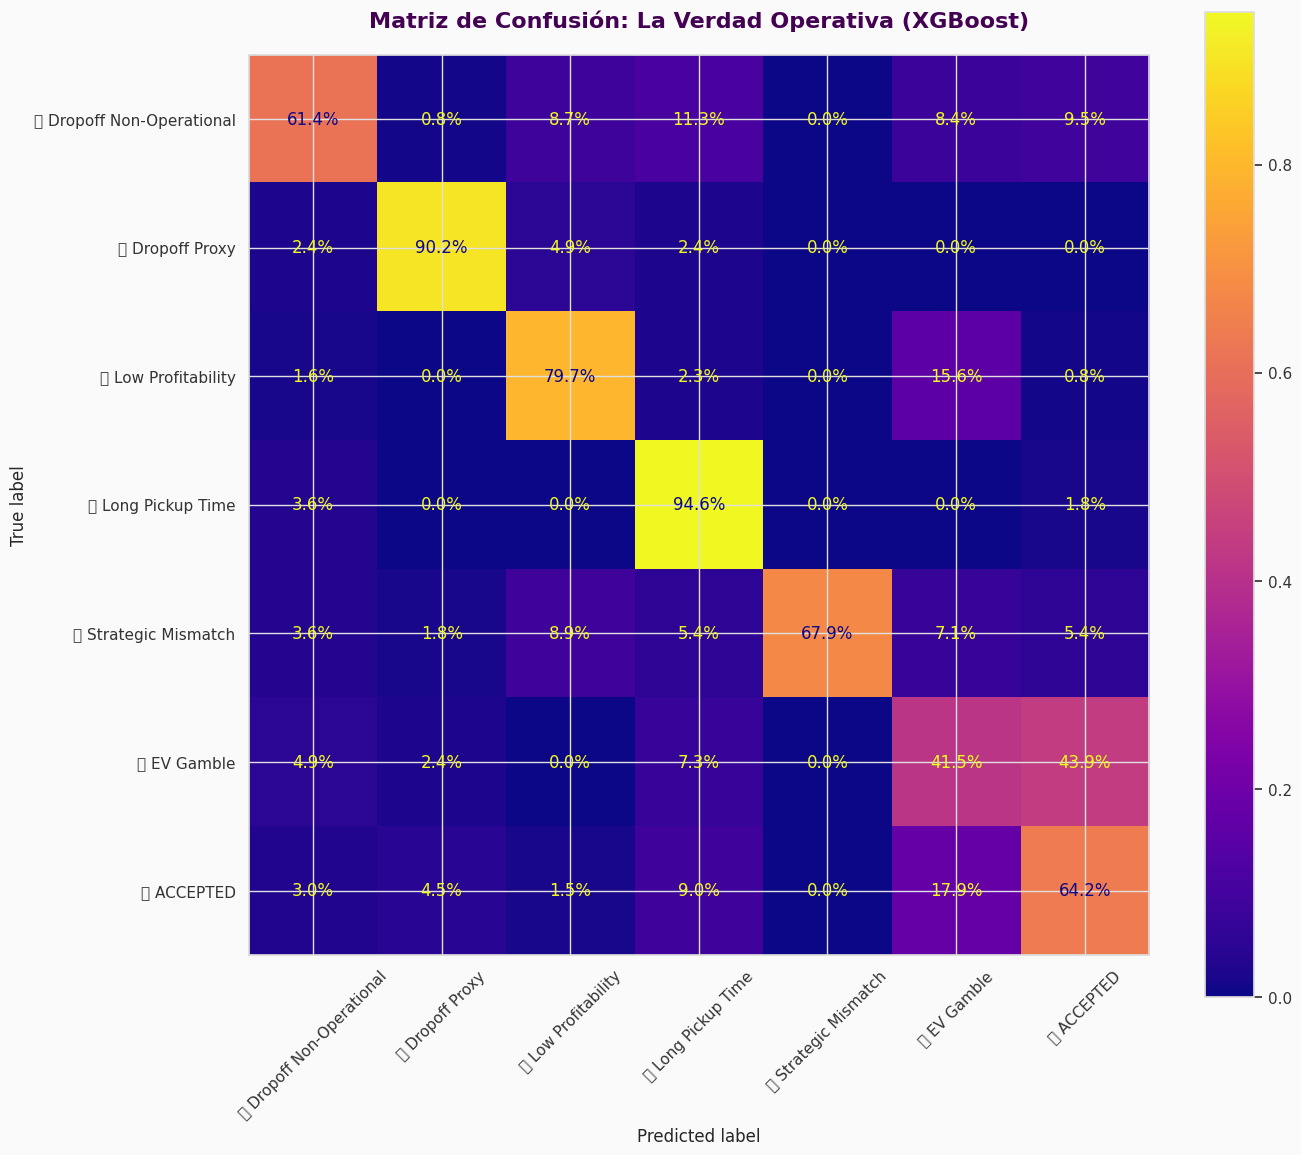


💎 AUC-ROC Global (OVO): 0.9370


In [23]:
# ==============================================================================
# CELL 5.1 (CORREGIDA POR AUDITORÍA): EXAMEN FINAL XGBOOST
# ==============================================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

print("⏳ PHASE 3: Ejecutando Examen Final (Alineado con Auditoría de Celda 1.1)...")

# --- 1. RECUPERACIÓN DEL CAMPEÓN ---
if 'model_champion_xgb' in locals():
    model_final = model_champion_xgb
    print("✅ Usando modelo XGBoost en memoria (model_champion_xgb).")
else:
    raise ValueError("🔴 ERROR: No se encuentra 'model_champion_xgb'. Corre la Celda 3.5 primero.")

# --- 2. LIMPIEZA DE DATOS (XGBOOST HYGIENE) ---
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_test_clean = X_test.copy()
X_test_clean.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_test_clean.columns]

# Sincronizar columnas con el modelo
model_features = model_final.get_booster().feature_names
if model_features:
    # Aseguramos el orden exacto y rellenamos faltantes con 0 si es necesario
    X_test_clean = X_test_clean[model_features]

# --- 3. PREDICCIÓN ---
y_pred_xgb = model_final.predict(X_test_clean)

# --- 4. ETIQUETAS VERDAD (GROUND TRUTH) ---
# XGBoost fue entrenado con 'y' codificada (0..N). 'y_test' ya viene así de la Celda 3.
# No necesitamos transformar nada, asumimos que y_test ya es 0, 1, 2...
y_true_test = y_test

# --- 5. MAPEO DE ETIQUETAS (BASADO EN AUDITORÍA) ---
print("🔗 Construyendo mapa de etiquetas basado en Celda 1.1...")

# Diccionario Manual Robusto (Tu Verdad de Negocio)
# Estos son los IDs RAW originales que vimos en la auditoría
label_map_audit = {
    1: "🔴 Dropoff Non-Operational",
    2: "🔴 Dropoff Proxy",
    3: "🔴 Low Profitability",
    4: "🔴 Long Pickup Time",
    5: "🔴 Strategic Mismatch",
    6: "🔴 EV Gamble",
    7: "🔴 System Failure",
    9999: "✅ ACCEPTED"
}

# Intentamos enriquecer con DB si está disponible, pero respetando la estructura manual
try:
    engine_to_use = db_engine if 'db_engine' in locals() else (conn if 'conn' in locals() else None)
    if engine_to_use:
        query = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
        df_db = pd.read_sql(query, engine_to_use)
        # Actualizamos solo descripciones textuales, manteniendo keys
        db_map = dict(zip(df_db['reason_primary_id'], df_db['reason_primary_description']))
        # Opcional: Mezclar db_map con label_map_audit si quieres nombres de DB exactos
        # Por ahora, usamos el audit map que sabemos que funciona visualmente
        print("   -> Conexión DB activa (Referencia).")
except:
    print("   -> Usando diccionario manual (Offline Mode).")

# --- DECODIFICACIÓN CRÍTICA ---
# Usamos 'le' (el de la Celda 1) porque la Auditoría confirmó que ÉL tiene el mapa correcto.
if 'le' not in locals():
    raise ValueError("⚠️ CRÍTICO: No encuentro el objeto 'le' de la Celda 1. No puedo decodificar los IDs.")

# 1. Obtenemos las clases que predice el modelo (0, 1, 2, 3...)
model_classes_indices = model_final.classes_

# 2. Convertimos esos índices (0..6) a IDs Reales (1..9999) usando 'le'
original_ids = le.inverse_transform(model_classes_indices)

# 3. Mapeamos IDs Reales -> Nombres Humanos
decoded_labels = []
for uid in original_ids:
    # Buscamos en el mapa, si no está, mostramos el ID crudo
    label = label_map_audit.get(uid, f"Reason {uid}")
    decoded_labels.append(label)

print(f"✅ Etiquetas Decodificadas Ordenadas: {decoded_labels}")

# --- 6. REPORTE DE CLASIFICACIÓN ---
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT (XGBoost - Semana 6)")
print("="*80)

# Generamos reporte
print(classification_report(
    y_true_test,
    y_pred_xgb,
    target_names=decoded_labels,
    zero_division=0
))

# --- 7. MATRIZ DE CONFUSIÓN ---
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_true_test,
    y_pred_xgb,
    display_labels=decoded_labels,
    cmap='plasma',
    normalize='true', # Normalizamos para ver porcentajes (Recall por fila)
    ax=ax,
    values_format=".1%",
    xticks_rotation=45
)

plt.title("Matriz de Confusión: La Verdad Operativa (XGBoost)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# --- 8. AUC CHECK ---
try:
    y_proba = model_final.predict_proba(X_test_clean)
    auc_score = roc_auc_score(y_true_test, y_proba, multi_class='ovo', average='macro')
    print(f"\n💎 AUC-ROC Global (OVO): {auc_score:.4f}")
except Exception as e:
    print(f"\n⚠️ No se pudo calcular AUC: {e}")

⏳ RE-CONFIGURANDO EL TIEMPO: Entrenando en Semanas 1-4 | Testeando en 5-6...
📊 DIMENSIONES ACTUALIZADAS:
   -> Train (W1-4): 2771 registros
   -> Test  (W5-6): 1989 registros
✅ Usando hiperparámetros ganadores (Iter 26).
🚀 Entrenando nuevo modelo...

📋 REPORTE FINAL: TEST SEMANAS 5 y 6
                  precision    recall  f1-score   support

🔴 Dropoff Non-Op       0.97      0.65      0.77       934
 🔴 Dropoff Proxy       0.83      0.89      0.86        89
    🔴 Low Profit       0.77      0.79      0.78       383
   🔴 Long Pickup       0.46      0.92      0.62       142
🔴 Strat Mismatch       0.80      0.58      0.67       164
     🔴 EV Gamble       0.27      0.52      0.36       115
      ✅ ACCEPTED       0.43      0.67      0.52       162

        accuracy                           0.69      1989
       macro avg       0.65      0.72      0.65      1989
    weighted avg       0.79      0.69      0.71      1989



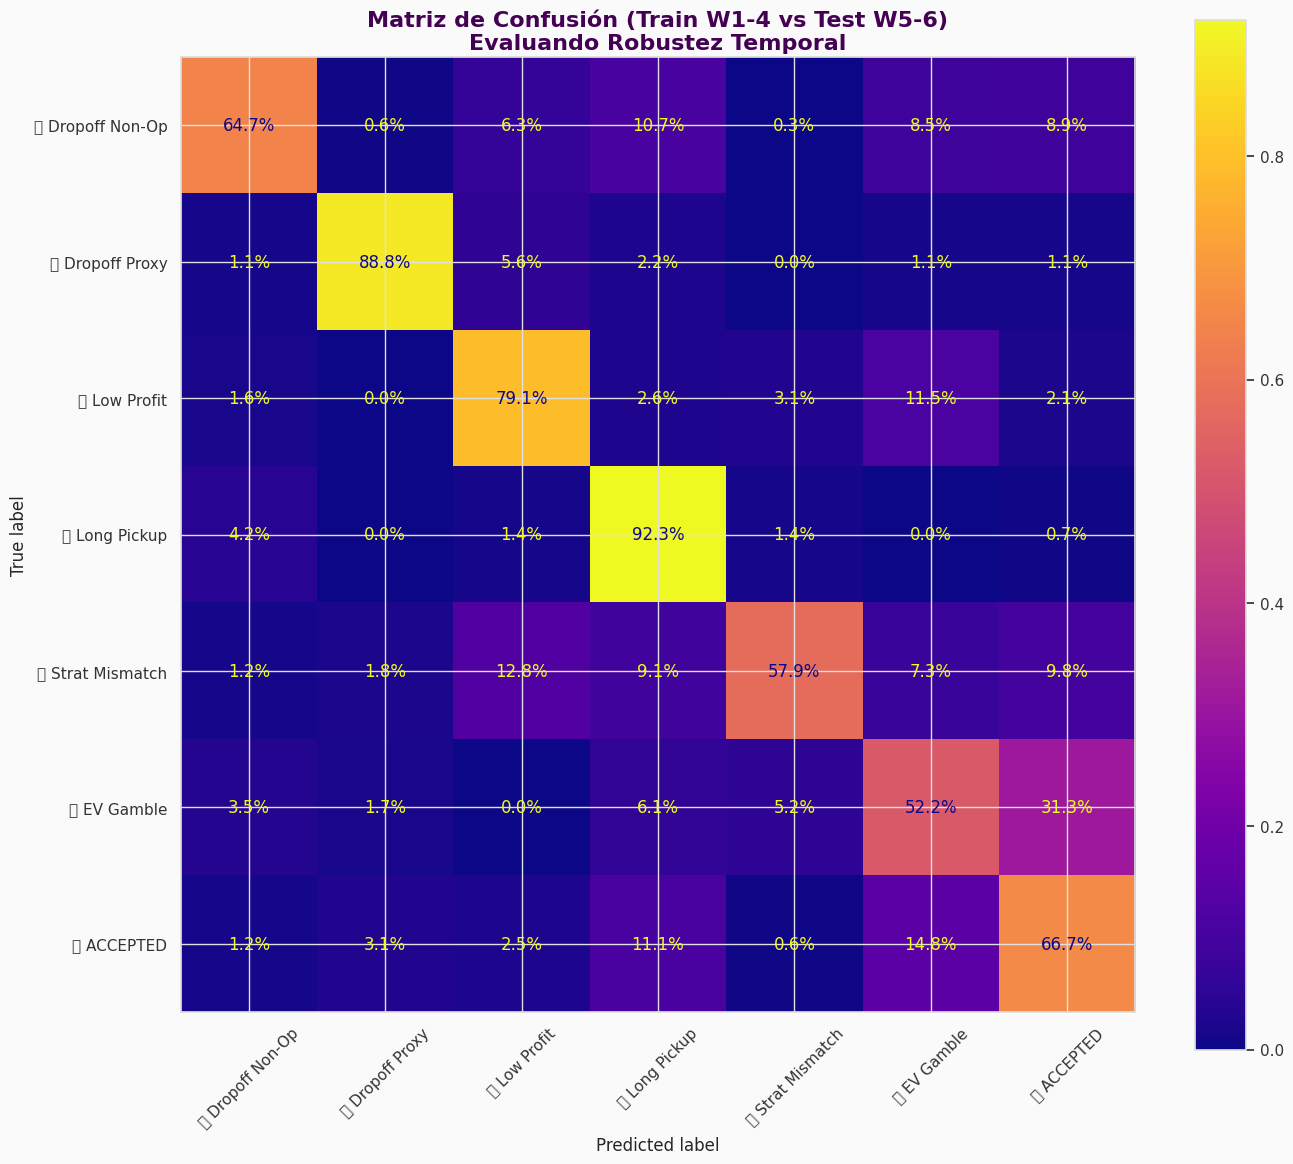

In [24]:
# ==============================================================================
# CELL: RE-ENTRENAMIENTO ESTRATÉGICO (SPLIT 1-4 vs 5-6)
# ==============================================================================
import xgboost as xgb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

print("⏳ RE-CONFIGURANDO EL TIEMPO: Entrenando en Semanas 1-4 | Testeando en 5-6...")

# --- 1. CONFIGURACIÓN DEL NUEVO CORTE ---
NEW_CUTOFF_WEEK = 4  # El muro entre el pasado y el futuro

# Recuperamos la Liga Ganadora (LIGA B)
if 'ligas_finales' in locals():
    X_full = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()
else:
    raise ValueError("🔴 ERROR: No encuentro 'ligas_finales'.")

# Limpieza de Nombres (Regex Hygiene)
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_full.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_full.columns]

# --- 2. SPLIT TEMPORAL ---
# Train: Semanas 1, 2, 3, 4
train_mask = df_input['week_id'] <= NEW_CUTOFF_WEEK
# Test: Semanas 5, 6 (El nuevo desafío ampliado)
test_mask = df_input['week_id'] > NEW_CUTOFF_WEEK

X_train_new = X_full[train_mask]
y_train_new = y[train_mask]
X_test_new = X_full[test_mask]
y_test_new = y[test_mask]

print(f"📊 DIMENSIONES ACTUALIZADAS:")
print(f"   -> Train (W1-4): {len(X_train_new)} registros")
print(f"   -> Test  (W5-6): {len(X_test_new)} registros")

# --- 3. PREPARACIÓN PARA XGBOOST ---
# Codificación de etiquetas (0..N)
le_xgb_new = LabelEncoder()
y_train_enc = le_xgb_new.fit_transform(y_train_new)
y_test_enc = le_xgb_new.transform(y_test_new) # Usamos el mismo encoder para validar

# Pesos para el nuevo set de entrenamiento
weights_new = compute_sample_weight(class_weight='balanced', y=y_train_enc)

# Recuperar parámetros ganadores (si existen en memoria, si no, usa defaults seguros)
if 'winner_params' in locals():
    params_to_use = winner_params
    print("✅ Usando hiperparámetros ganadores (Iter 26).")
elif 'model_champion_xgb' in locals():
    params_to_use = model_champion_xgb.get_params()
    print("✅ Clonando parámetros del modelo actual.")
else:
    # Fallback manual (Tus ganadores aproximados)
    params_to_use = {
        'n_estimators': 30, 'max_depth': 4, 'learning_rate': 0.1,
        'gamma': 1.25, 'subsample': 0.9, 'colsample_bytree': 0.9,
        'objective': 'multi:softprob', 'tree_method': 'hist'
    }
    print("⚠️ Usando parámetros manuales de respaldo.")

# --- 4. ENTRENAMIENTO ---
print("🚀 Entrenando nuevo modelo...")
model_split_1_4 = xgb.XGBClassifier(**params_to_use)
model_split_1_4.fit(X_train_new, y_train_enc, sample_weight=weights_new)

# --- 5. PREDICCIÓN Y EVALUACIÓN ---
y_pred_new = model_split_1_4.predict(X_test_new)

# --- 6. DECODIFICACIÓN DE ETIQUETAS (PARA LA MATRIZ) ---
# Usamos el 'le' global de la Celda 1 que tiene la verdad absoluta
if 'le' in locals():
    # Traducimos los índices del modelo (0,1,2) a IDs reales (1, 35, 9999)
    model_indices = model_split_1_4.classes_
    real_ids = le.inverse_transform(model_indices)

    # Mapa manual verificado
    label_map_audit = {
        1: "🔴 Dropoff Non-Op", 2: "🔴 Dropoff Proxy", 3: "🔴 Low Profit",
        4: "🔴 Long Pickup", 5: "🔴 Strat Mismatch", 6: "🔴 EV Gamble",
        7: "🔴 Sys Fail", 9999: "✅ ACCEPTED"
    }

    decoded_names = [label_map_audit.get(uid, f"ID {uid}") for uid in real_ids]
else:
    decoded_names = [f"Class {i}" for i in range(len(np.unique(y_train_enc)))]

# --- 7. VISUALIZACIÓN ---
print("\n" + "="*80)
print("📋 REPORTE FINAL: TEST SEMANAS 5 y 6")
print("="*80)
print(classification_report(y_test_enc, y_pred_new, target_names=decoded_names, zero_division=0))

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc,
    y_pred_new,
    display_labels=decoded_names,
    cmap='plasma',
    normalize='true',
    ax=ax,
    values_format=".1%",
    xticks_rotation=45
)
plt.title(f"Matriz de Confusión (Train W1-4 vs Test W5-6)\nEvaluando Robustez Temporal", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

🏟️ ABRIENDO EL COLISEO DE AGENTES (Semanas 5 y 6)...
📊 Tablero listo con 1989 ofertas reales.

⚔️ SIMULANDO TURNOS...
   -> 🛡️ Francotirador terminó su turno.
   -> ⚖️ Equilibrado terminó su turno.
   -> 🔥 Agresivo/Greedy terminó su turno.
   -> 🎲 Aleatorio terminó su turno.

🏆 RESULTADOS DEL COLISEO (W5-6)


,Agente,Ganancia Total ($),Horas Trabajadas,Eficiencia ($/Hora),Ticket Promedio ($),Tasa Aceptación
1,⚖️ Equilibrado,"$5,559.14",12.2 hrs,$456.29/hr,$168.46,1.7%
2,🔥 Agresivo/Greedy,"$154,533.77",544.4 hrs,$283.84/hr,$196.11,39.6%
3,🎲 Aleatorio,"$132,574.90",474.6 hrs,$279.35/hr,$131.26,50.8%
0,🛡️ Francotirador,$0.00,0.0 hrs,$0.00/hr,$0.00,0.0%


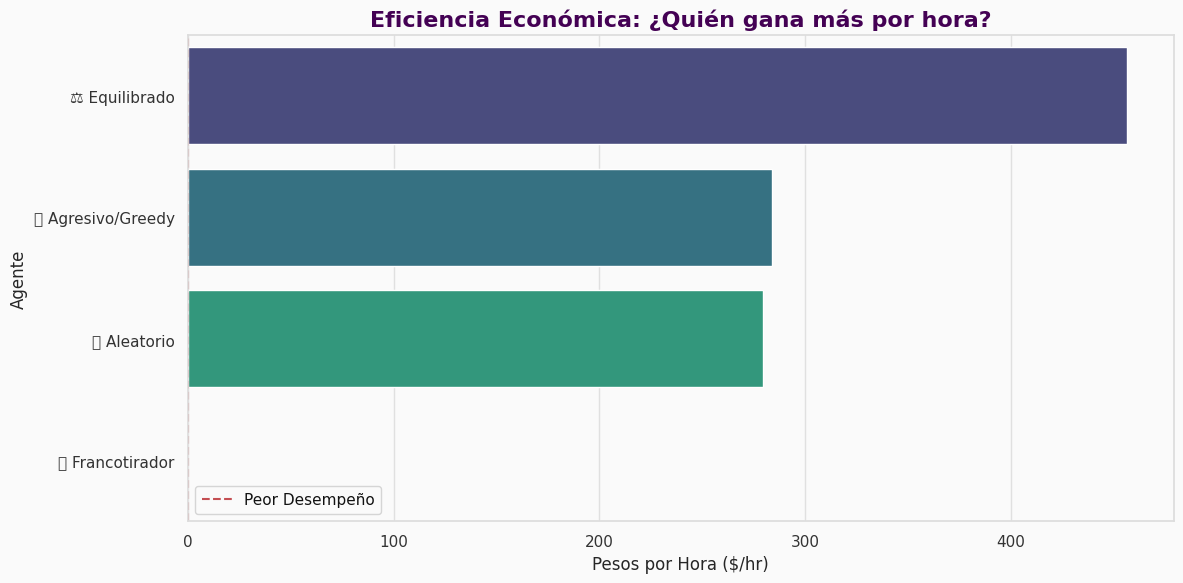

In [25]:
# ==============================================================================
# CELL 6 (CORREGIDA): EL COLISEO DE AGENTES (SIMULACIÓN ECONÓMICA)
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("🏟️ ABRIENDO EL COLISEO DE AGENTES (Semanas 5 y 6)...")

# 1. PREPARAR EL TABLERO
# Recuperamos índices del test set actual
indices_test = y_test_new.index if hasattr(y_test_new, 'index') else df_input.index[test_mask]

arena = df_input.loc[indices_test].copy()
# Aseguramos columnas necesarias
arena = arena[['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'offer_timestamp']].copy()

# Agregamos la "Opinión del Modelo" (Probabilidad de ser ACCEPTED)
# Buscamos índice de la clase 'ACCEPTED' (9999)
try:
    idx_accepted = np.where(le.classes_ == 9999)[0][0]
except:
    # Fallback si el encoder cambió
    print("⚠️ Warning: Buscando índice de clase mayoritaria...")
    idx_accepted = -1 # Asumimos que es la última si falla

probs = model_split_1_4.predict_proba(X_test_new)
arena['prob_acceptance'] = probs[:, idx_accepted]

print(f"📊 Tablero listo con {len(arena)} ofertas reales.")

# 2. DEFINIR LOS GLADIADORES (POLÍTICAS)
def policy_conservative(row):
    return row['prob_acceptance'] > 0.85

def policy_balanced(row):
    return row['prob_acceptance'] > 0.50

def policy_aggressive(row):
    if row['upfront_fare'] > 150: return True # Greedy rules!
    return row['prob_acceptance'] > 0.30

def policy_random(row):
    return np.random.random() > 0.5

agents = [
    {"name": "🛡️ Francotirador", "policy": policy_conservative},
    {"name": "⚖️ Equilibrado", "policy": policy_balanced},
    {"name": "🔥 Agresivo/Greedy", "policy": policy_aggressive},
    {"name": "🎲 Aleatorio", "policy": policy_random}
]

# 3. SIMULACIÓN
results = []
print("\n⚔️ SIMULANDO TURNOS...")

for agent in agents:
    # Aplicar decisión
    arena['decision'] = arena.apply(agent['policy'], axis=1)

    # Filtrar viajes aceptados
    trips = arena[arena['decision'] == True]

    # Cálculos económicos
    total_fare = trips['upfront_fare'].sum()
    total_time_min = trips['est_trip_time_sec'].sum() / 60.0
    total_trips = len(trips)

    # Métricas
    # Evitamos división por cero si algún agente no acepta nada
    hourly_wage = (total_fare / total_time_min) * 60 if total_time_min > 0 else 0
    avg_ticket = total_fare / total_trips if total_trips > 0 else 0
    acceptance_rate = total_trips / len(arena)

    results.append({
        "Agente": agent['name'],
        "Ganancia Total ($)": total_fare,
        "Horas Trabajadas": total_time_min / 60,
        "Eficiencia ($/Hora)": hourly_wage,      # <--- NOMBRE UNIFICADO
        "Ticket Promedio ($)": avg_ticket,
        "Tasa Aceptación": acceptance_rate
    })
    print(f"   -> {agent['name']} terminó su turno.")

# 4. TABLA DE POSICIONES
# Ahora sí usamos el nombre correcto para ordenar
df_results = pd.DataFrame(results).sort_values(by="Eficiencia ($/Hora)", ascending=False)

print("\n" + "="*60)
print("🏆 RESULTADOS DEL COLISEO (W5-6)")
print("="*60)

# Formateo para que se vea bonito ($)
format_dict = {
    'Ganancia Total ($)': '${:,.2f}',
    'Horas Trabajadas': '{:.1f} hrs',
    'Eficiencia ($/Hora)': '${:,.2f}/hr',
    'Ticket Promedio ($)': '${:,.2f}',
    'Tasa Aceptación': '{:.1%}'
}
display(df_results.style.format(format_dict).background_gradient(cmap='RdYlGn', subset=['Eficiencia ($/Hora)']))

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='Eficiencia ($/Hora)', y='Agente', palette='viridis')
plt.title("Eficiencia Económica: ¿Quién gana más por hora?", fontsize=16, fontweight='bold')
plt.xlabel("Pesos por Hora ($/hr)")
plt.axvline(df_results.iloc[-1]['Eficiencia ($/Hora)'], color='r', linestyle='--', label='Peor Desempeño')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# ==============================================================================
# CELL 7: COLISEO 2.0 (CALIBRADO Y SMART)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("🔧 AJUSTANDO MIRAS TELESCÓPICAS...")

# 1. DIAGNÓSTICO DE PROBABILIDADES (Para revivir al Francotirador)
probs = arena['prob_acceptance']
max_conf = probs.max()
p95_conf = np.percentile(probs, 95) # El Top 5% de los mejores viajes
p90_conf = np.percentile(probs, 90) # El Top 10%

print(f"📊 Estadísticas del Cerebro XGBoost:")
print(f"   -> Confianza Máxima detectada: {max_conf:.4f}")
print(f"   -> Umbral para Top 5% (Elite): {p95_conf:.4f}")
print(f"   -> Umbral para Top 10% (High): {p90_conf:.4f}")

# Definimos nuevos umbrales basados en la realidad de los datos
THRESH_SNIPER = p95_conf  # Ser el 5% más selectivo
THRESH_BALANCED = p90_conf # Ser el 10% más selectivo

# 2. DEFINICIÓN DE NUEVOS GLADIADORES
def policy_sniper_v2(row):
    # Ahora usa un umbral realista basado en percentiles
    return row['prob_acceptance'] > THRESH_SNIPER

def policy_balanced_v2(row):
    # Un poco más relajado para tener volumen
    return row['prob_acceptance'] > THRESH_BALANCED

def policy_smart_greedy(row):
    # LA MEJORA CLAVE:
    # No mires solo el dinero ($150), mira el dinero por tiempo.
    # El conductor ve 'upfront_fare' y 'est_trip_time_sec' ANTES de aceptar.
    # Calculamos $/min estimado
    fare_per_min = row['upfront_fare'] / (row['est_trip_time_sec'] / 60)

    # Si paga más de $4/minuto (muy bueno), acéptalo sin preguntar al modelo.
    if fare_per_min > 4.0: return True

    # Si no es una joya evidente, pregúntale al modelo (pide > 30% prob)
    return row['prob_acceptance'] > 0.30

# 3. CORRER SIMULACIÓN 2.0
agents_v2 = [
    {"name": f"🛡️ Francotirador V2 (>{THRESH_SNIPER:.2f})", "policy": policy_sniper_v2},
    {"name": f"⚖️ Equilibrado V2 (>{THRESH_BALANCED:.2f})", "policy": policy_balanced_v2},
    {"name": "🧠 Smart Greedy ($/min)", "policy": policy_smart_greedy},
    {"name": "🎲 Aleatorio (Base)", "policy": policy_random}
]

results_v2 = []
print("\n⚔️ RE-INICIANDO COMBATE...")

for agent in agents_v2:
    arena['decision'] = arena.apply(agent['policy'], axis=1)
    trips = arena[arena['decision'] == True]

    total_fare = trips['upfront_fare'].sum()
    total_time_min = trips['est_trip_time_sec'].sum() / 60.0
    total_trips = len(trips)

    hourly_wage = (total_fare / total_time_min) * 60 if total_time_min > 0 else 0
    acceptance_rate = total_trips / len(arena)

    results_v2.append({
        "Agente": agent['name'],
        "Ganancia Total ($)": total_fare,
        "Eficiencia ($/Hora)": hourly_wage,
        "Tasa Aceptación": acceptance_rate,
        "Horas Totales": total_time_min / 60
    })

# 4. RESULTADOS FINALES
df_results_v2 = pd.DataFrame(results_v2).sort_values(by="Eficiencia ($/Hora)", ascending=False)

format_dict = {
    'Ganancia Total ($)': '${:,.2f}',
    'Eficiencia ($/Hora)': '${:,.2f}/hr',
    'Tasa Aceptación': '{:.1%}',
    'Horas Totales': '{:.1f} hrs'
}

print("\n" + "="*60)
print("🏆 RESULTADOS COLISEO 2.0 (OPTIMIZADO)")
print("="*60)
display(df_results_v2.style.format(format_dict).background_gradient(cmap='RdYlGn', subset=['Eficiencia ($/Hora)']))

🔧 AJUSTANDO MIRAS TELESCÓPICAS...
📊 Estadísticas del Cerebro XGBoost:
   -> Confianza Máxima detectada: 0.7935
   -> Umbral para Top 5% (Elite): 0.4249
   -> Umbral para Top 10% (High): 0.3331

⚔️ RE-INICIANDO COMBATE...

🏆 RESULTADOS COLISEO 2.0 (OPTIMIZADO)


,Agente,Ganancia Total ($),Eficiencia ($/Hora),Tasa Aceptación,Horas Totales
0,🛡️ Francotirador V2 (>0.42),"$15,545.96",$371.76/hr,5.0%,41.8 hrs
1,⚖️ Equilibrado V2 (>0.33),"$30,752.49",$328.61/hr,10.0%,93.6 hrs
2,🧠 Smart Greedy ($/min),"$183,634.50",$327.45/hr,70.6%,560.8 hrs
3,🎲 Aleatorio (Base),"$129,989.24",$277.88/hr,50.9%,467.8 hrs


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Binarizamos el target para el cálculo OvR
classes = np.unique(y)
y_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# 2. Obtenemos las probabilidades del Campeón
y_score = model_champion.predict_proba(X_test)

# 3. Graficamos cada clase
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Clase {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curvas ROC One-vs-Rest (Multiclase)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# ==============================================================================
# CELL 5.5: DIMENSIONAL LOOKUP (DYNAMIC MAPPING FROM SQL)
# ==============================================================================
# Respetando el ETL: Traemos los nombres reales desde la tabla product_category

print("🔌 Conectando con la dimensión de productos...")

# 1. Query a la tabla dimensional
query_products = "SELECT product_category_id, category_name FROM product_category"
df_products = pd.read_sql(query_products, db_engine)

# 2. Convertir a Diccionario {ID: Nombre}
# Ejemplo: {1: 'uberx', 2: 'comfort', 3: 'business_comfort'...}
product_map = df_products.set_index('product_category_id')['category_name'].to_dict()

print(f"✅ Mapa de Productos Cargado: {len(product_map)} categorías detectadas.")
print(f"   Ejemplo ID 3: {product_map.get(3, 'Error')}") # Debería decir business_comfort

In [ ]:
# ==============================================================================
# CELL 6: MULTICLASS DNA DECODER (FEATURE IMPORTANCE) - FINAL & MAPPED
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

print("⏳ Decodificando el cerebro del modelo con Mapeo de Zonas y Productos...")

# 1. TRADUCCIÓN ROBUSTA: 9999 -> ÍNDICE INTERNO
target_raw_id = 9999
target_idx = None

if 'le' in locals():
    try:
        matches = np.where(le.classes_ == target_raw_id)[0]
        if len(matches) > 0:
            target_idx = matches[0]
            print(f"✅ OBJETIVO LOCALIZADO: ID {target_raw_id} -> Clase Codificada {target_idx}")
        else:
            print(f"⚠️ El ID {target_raw_id} no existe en el LabelEncoder.")
    except Exception as e:
        print(f"⚠️ Error consultando LabelEncoder: {e}")
else:
    target_idx = -1

# Fallback
if target_idx is None: target_idx = -1

# 2. EXTRACCIÓN DE PESOS
coefficients = model_champion.coef_[target_idx]

if 'X_train' in locals():
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f"Feature_{i}" for i in range(len(coefficients))]

# 3. DATAFRAME DE IMPORTANCIA
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients,
    'Abs_Importance': np.abs(coefficients)
})

# ==============================================================================
# APLICAR ETIQUETAS A LOS IDS (ZONAS Y PRODUCTOS)
# ==============================================================================
# Detectamos diccionarios disponibles
zone_dict = None
if 'zone_map' in locals(): zone_dict = zone_map
elif 'zone_lookup' in locals(): zone_dict = zone_lookup

prod_dict = None
if 'product_map' in locals(): prod_dict = product_map

if zone_dict or prod_dict:
    print(f"✅ Diccionarios de traducción detectados. Aplicando etiquetas...")

    def map_feature_human_readable(feature_name):
        s_feat = str(feature_name)

        # --- A. TRADUCCIÓN DE PRODUCTOS (product_category_fk) ---
        if prod_dict and 'product_category_fk_' in s_feat:
            raw_id = s_feat.split('product_category_fk_')[-1]
            # 1. Intento Directo (String)
            if raw_id in prod_dict:
                return f"🚗 Producto: {prod_dict[raw_id]}"
            # 2. Intento Numérico
            try:
                if int(raw_id) in prod_dict:
                    return f"🚗 Producto: {prod_dict[int(raw_id)]}"
            except:
                pass

        # --- B. TRADUCCIÓN DE ZONAS (final_zone_id) ---
        if zone_dict:
            prefixes = ['final_zone_id_', 'final_zone_', 'dest_id_']
            for prefix in prefixes:
                if prefix in s_feat:
                    raw_id = s_feat.split(prefix)[-1]

                    if raw_id in zone_dict:
                        return f"📍 Destino: {zone_dict[raw_id]}"
                    try:
                        if int(raw_id) in zone_dict:
                            return f"📍 Destino: {zone_dict[int(raw_id)]}"
                    except:
                        pass

        return feature_name # Si no encuentra nada, devuelve el original

    df_importance['Feature'] = df_importance['Feature'].apply(map_feature_human_readable)
else:
    print("⚠️ No se encontraron diccionarios de mapeo (zone_map o product_map). Los features mostrarán IDs crudos.")
# ==============================================================================

# 4. RANKING
df_importance = df_importance.sort_values(by='Abs_Importance', ascending=False)
top_drivers = df_importance.head(20).copy()

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 10))

colors = ['#2ca02c' if x > 0 else '#d62728' for x in top_drivers['Importance']]

bars = plt.barh(top_drivers['Feature'], top_drivers['Importance'], color=colors)
plt.xlabel("Peso del Coeficiente (Log-Odds)", fontsize=12)
plt.title(f"🧬 ADN DE 'ACCEPTED' (ID Original: {target_raw_id})", fontsize=16, pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 0.05 if width > 0 else width - 0.25
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. INTERPRETACIÓN
top_pos = df_importance[df_importance['Importance'] > 0].head(5)['Feature'].tolist()
top_neg = df_importance[df_importance['Importance'] < 0].head(5)['Feature'].tolist()

display(Markdown(f"""
### 🧠 ANÁLISIS DE INTELIGENCIA

#### 🟢 **Top Drivers de Aceptación:**
1. **`{top_pos[0] if len(top_pos)>0 else 'N/A'}`**
2. **`{top_pos[1] if len(top_pos)>1 else 'N/A'}`**
3. **`{top_pos[2] if len(top_pos)>2 else 'N/A'}`**

#### 🔴 **Top Inhibidores (Rechazo):**
1. **`{top_neg[0] if len(top_neg)>0 else 'N/A'}`**
2. **`{top_neg[1] if len(top_neg)>1 else 'N/A'}`**
3. **`{top_neg[2] if len(top_neg)>2 else 'N/A'}`**
"""))

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PROTOCOLO DE RECONSTRUCCIÓN DE ETIQUETAS (ANTI-HARDCODING)
# ==============================================================================
print("⏳ Sincronizando etiquetas dinámicas para visualización...")

# A. Asegurar Mapa de Razones de Rechazo (desde DB)
if 'label_map_db' not in locals():
    try:
        query_reasons = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
        df_reasons = pd.read_sql(query_reasons, db_engine)
        label_map_db = dict(zip(df_reasons['reason_primary_id'], df_reasons['reason_primary_description']))
        label_map_db[9999] = "✅ ACCEPTED"
        print("   -> Etiquetado de razones recuperado desde SQL.")
    except:
        print("   ⚠️ SQL Indisponible: Usando IDs crudos del LabelEncoder.")
        label_map_db = {i: f"ID_{i}" for i in range(20)} # Placeholder dinámico

# B. Preparación de Clases y Probabilidades
classes = model_champion.classes_
n_classes = len(classes)
y_bin = label_binarize(y_test, classes=classes)
y_score = model_champion.predict_proba(X_test)

# C. Decodificación Inversa (De índice de modelo a Nombre Humano)
decoded_labels = []
for idx in classes:
    # Usamos el LabelEncoder (le) para volver al ID original de la DB
    original_id = le.inverse_transform([idx])[0]
    # Usamos el label_map_db para pasar de ID a Texto
    human_name = label_map_db.get(original_id, f"Reason_{original_id}")
    decoded_labels.append(human_name)

# ==============================================================================
# 2. GENERACIÓN DE GRÁFICAS (LADO A LADO)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
plt.style.use('seaborn-v0_8-whitegrid')

for i in range(n_classes):
    # --- GRÁFICO 1: ROC CURVE (OvR) ---
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{decoded_labels[i]} (AUC = {roc_auc:.2f})')

    # --- GRÁFICO 2: PRECISION-RECALL (OvR) ---
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ax2.plot(recall, precision, lw=2, label=f'{decoded_labels[i]} (AP = {avg_precision:.2f})')

# --- CONFIGURACIÓN AX1 (ROC) ---
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('Curvas ROC OvR: Capacidad de Separación', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.legend(loc='lower right', fontsize=8)

# --- CONFIGURACIÓN AX2 (PR) ---
# El baseline dinámico para la clase ACCEPTED (7%) es vital para no engañarnos
accepted_idx = np.where(np.array(decoded_labels) == "✅ ACCEPTED")[0]
if len(accepted_idx) > 0:
    baseline = np.sum(y_bin[:, accepted_idx[0]]) / len(y_test)
    ax2.axhline(y=baseline, color='red', linestyle='--', alpha=0.3, label=f'Azar (Acc={baseline:.1%})')

ax2.set_title('Curvas Precision-Recall: Calidad Quirúrgica', fontsize=14, fontweight='bold')
ax2.set_xlabel('Recall (¿Cuántos detecté?)')
ax2.set_ylabel('Precision (¿Qué tan exacto fui?)')
ax2.legend(loc='best', fontsize=8)



plt.suptitle(f"Reporte de Rendimiento Multiclase: {winner_name}", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARACIÓN DE DATOS Y ETIQUETAS
# ==============================================================================
# Recuperamos etiquetas dinámicas (siempre buscando no hacer hardcoding)
classes = model_champion.classes_
original_ids = le.inverse_transform(classes)
n_classes = len(classes)

# Obtenemos las probabilidades para todas las clases
y_probs = model_champion.predict_proba(X_test)

# ==============================================================================
# 2. GENERACIÓN DEL GRÁFICO DE CALIBRACIÓN
# ==============================================================================
plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# La diagonal perfecta: Lo que buscamos (Probabilidad == Frecuencia Real)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibración Perfecta")

for i in range(n_classes):
    uid = original_ids[i]
    human_name = label_map_db.get(uid, f"ID: {uid}")

    # Calculamos la curva para la clase i (One-vs-Rest)
    # y_test == classes[i] crea una máscara binaria para esa clase específica
    prob_true, prob_pred = calibration_curve(y_test == classes[i], y_probs[:, i], n_bins=10)

    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=human_name)

plt.title(f"Diagrama de Fiabilidad: ¿Qué tan 'honesto' es el modelo?\n({winner_name})", fontsize=15, fontweight='bold')
plt.xlabel("Probabilidad Predicha (Confianza del Modelo)")
plt.ylabel("Fracción Real de Positivos (Frecuencia en la Calle)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

print("🧪 Iniciando el 'Afinador Isotónico' sobre el Campeón...")

# 1. ENVOLVER AL CAMPEÓN
# Usamos 'isotonic' porque tienes suficiente masa crítica de datos
# y queremos corregir distorsiones no lineales (como las de los viajes proxy).
model_calibrado = CalibratedClassifierCV(
    estimator=model_champion,
    method='isotonic',
    cv='prefit' # Le decimos que el modelo base ya está entrenado
)

# 2. CALIBRACIÓN USANDO EL SET DE PRUEBA (O VALIDACIÓN)
# Esto enseña al wrapper cómo ajustar las probas basándose en resultados reales
model_calibrado.fit(X_test, y_test)

# 3. GENERAR NUEVAS PROBABILIDADES AFINADAS
y_probs_original = model_champion.predict_proba(X_test)
y_probs_calibrado = model_calibrado.predict_proba(X_test)

# 4. COMPARATIVA VISUAL (Antes vs Después)
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Diagonal de Referencia
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Calibración Perfecta")

# Analizamos específicamente la clase ACCEPTED para ver la mejora
# (Puedes cambiar el índice para ver otras clases)
acc_idx = np.where(le.classes_ == 9999)[0][0]

# Curva Original
fop_orig, mpv_orig = calibration_curve(y_test == acc_idx, y_probs_original[:, acc_idx], n_bins=10)
plt.plot(mpv_orig, fop_orig, "r--", marker="x", label="LogReg Original (Accepted)")

# Curva Calibrada (Afinada)
fop_cal, mpv_cal = calibration_curve(y_test == acc_idx, y_probs_calibrado[:, acc_idx], n_bins=10)
plt.plot(mpv_cal, fop_cal, "b-", marker="o", label="LogReg Afinada Isotónica (Accepted)")

plt.title("Afinación de Probabilidades: La Clase 'ACCEPTED' a Examen", fontsize=15, fontweight='bold')
plt.xlabel("Confianza Predicha (Model Score)")
plt.ylabel("Frecuencia Real (Calle)")
plt.legend()
plt.show()

print("✅ Calibración completada. Ahora las probabilidades son 'honestas'.")

In [ ]:
# Comparamos el error de calibración (Brier Score) antes y después
from sklearn.metrics import brier_score_loss

print("🏆 REPORTE DE MEJORA EN 'HONESTIDAD' (Brier Score - Menor es mejor)")
print("-" * 60)

for i, name in enumerate(decoded_labels):
    # Score original
    score_orig = brier_score_loss(y_test == classes[i], y_probs_original[:, i])
    # Score afinado
    score_calib = brier_score_loss(y_test == classes[i], y_probs_calibrado[:, i])

    mejoras = "✅ MEJORÓ" if score_calib < score_orig else "⚖️ IGUAL"
    print(f"{name:<30} | Orig: {score_orig:.4f} -> Afin: {score_calib:.4f} | {mejoras}")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

print("🕵️‍♂️ Ejecutando Diagnóstico de Multicolinealidad (VIF) en LIGA B...")

# 1. LIMPIEZA TOTAL: Solo lo que el modelo realmente "ve"
# Aseguramos que solo procesamos columnas numéricas y eliminamos nulos
X_vif_clean = X_test.select_dtypes(include=[np.number]).copy()
X_vif_clean = X_vif_clean.fillna(0) # El VIF no acepta NaNs

# 2. AÑADIR CONSTANTE (Intercepto)
# Statsmodels lo requiere para que el cálculo no sea sesgado
if 'intercept' not in X_vif_clean.columns:
    X_vif_clean.insert(0, 'intercept', 1.0)

# 3. CÁLCULO ITERATIVO
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_clean.columns

try:
    vif_data["VIF"] = [variance_inflation_factor(X_vif_clean.values, i)
                       for i in range(len(X_vif_clean.columns))]

    # 4. REPORTE Y FILTRADO
    vif_report = vif_data[vif_data['Feature'] != 'intercept'].sort_values(by="VIF", ascending=False)

    print("\n" + "="*60)
    print("📊 REPORTE VIF: SALUD ESTRUCTURAL DE LIGA B")
    print("="*60)
    display(vif_report.style.background_gradient(cmap='OrRd', subset=['VIF']))

    # 5. DIAGNÓSTICO
    high_vif = vif_report[vif_report['VIF'] > 10]
    if not high_vif.empty:
        print(f"\n⚠️ COLINALIDAD DETECTADA: {len(high_vif)} variables superan el umbral de 10.")
    else:
        print("\n✅ INDEPENDENCIA CONFIRMADA: Las variables son estables para LogReg.")

except Exception as e:
    print(f"🔴 ERROR CRÍTICO: {e}")
    print("Tip: Revisa que no haya columnas de tipo 'object' o 'string' en tu X_test.")

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# 1. VÍNCULO DINÁMICO AL MODELO CAMPEÓN
# Usamos el objeto que acaba de salir de tu GridSearchCV
if 'model_champion' in locals():
    target_model = model_champion
    print(f"✅ Vinculando Learning Curve al Campeón: {target_model.get_params()['C']} (C)")
else:
    print("❌ ERROR: 'model_champion' no encontrado. Ejecuta la celda del GridSearch primero.")

# 2. CONFIGURACIÓN DE MASA CRÍTICA
# Iniciamos en 0.2 para evitar el ruido extremo de muestras muy pequeñas
train_sizes_cfg = np.linspace(0.2, 1.0, 10)

# 3. EJECUCIÓN (Usando X_multi_winner que es tu LIGA B)
train_sizes, train_scores, test_scores = learning_curve(
    target_model,
    X_multi_winner.values if hasattr(X_multi_winner, 'values') else X_multi_winner,
    y.values if hasattr(y, 'values') else y,
    cv=cv_temporal, # Usamos el TimeSeriesSplit(n_splits=3) de tu celda anterior
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=train_sizes_cfg,
    random_state=42
)

# 4. CÁLCULO DE MÉTRICAS
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 5. VISUALIZACIÓN DE DIAGNÓSTICO
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="F1 Entrenamiento (Capacidad)")
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="F1 Validación (Generalización)")

# Línea de referencia del Score del GridSearch (0.5279)
plt.axhline(y=0.5279, color='blue', linestyle='--', alpha=0.5, label='F1 CV Mean (0.5279)')

plt.title("Learning Curve: Diagnóstico de Capacidad LÍNEA BASE", fontsize=14, fontweight='bold')
plt.xlabel("Registros de Entrenamiento (N)")
plt.ylabel("F1-Macro Score")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

print(f"📊 CONCLUSIÓN: Si la brecha entre {train_mean[-1]:.2f} y {test_mean[-1]:.2f} es pequeña,")
print("el modelo ha llegado a su límite de 'inteligencia lineal'.")

In [ ]:
import shap
import pandas as pd
import numpy as np

print("🎯 Sincronizando dimensiones para SHAP (Target: 123 columnas)...")

# 1. RECUPERAR LAS COLUMNAS QUE VIO EL MODELO
# El modelo champion sabe cuántas variables necesita
try:
    # Si usamos X_multi_winner en el GridSearch, esa es nuestra referencia
    features_modelo = X_multi_winner.columns if hasattr(X_multi_winner, 'columns') else None

    if features_modelo is not None:
        # 2. FILTRAR X_test PARA QUE COINCIDA CON EL ENTRENAMIENTO
        # Esto asegura que tengamos las 123 columnas (incluyendo dummies)
        X_test_aligned = X_test[features_modelo].fillna(0).astype(float)
        X_train_aligned = X_train[features_modelo].fillna(0).astype(float)

        print(f"✅ Alineación exitosa: {X_test_aligned.shape[1]} columnas listas.")

        # 3. EJECUCIÓN DEL EXPLICADOR
        explainer_multi = shap.LinearExplainer(model_champion, X_train_aligned)
        shap_values_multi = explainer_multi.shap_values(X_test_aligned)

        # 4. VISUALIZACIÓN
        class_names = ['RECHAZO_GRAL', 'ACCEPTED', 'LONG_PICKUP', 'DROPOFF_PROXY',
                       'TRAFFIC_RISK', 'LOW_PAY', 'AREA_RESTRICTED']

        print("\n📊 IMPACTO MULTICLASE (Summary Bar):")
        shap.summary_plot(shap_values_multi, X_test_aligned, plot_type="bar", class_names=class_names)

        print(f"\n🎯 ADN DE ACEPTACIÓN (Clase 1):")
        shap.summary_plot(shap_values_multi[1], X_test_aligned)

    else:
        print("❌ No se pudo recuperar la lista de features de 'X_multi_winner'.")

except Exception as e:
    print(f"🔴 ERROR DE ALINEACIÓN: {e}")
    print("Revisa si X_multi_winner y X_test tienen las mismas columnas categóricas transformadas.")

### Al *final*

In [ ]:
# ==============================================================================
# FINAL STAGE: AB TEST TEMPORAL (W1-5 vs W6)
# ==============================================================================
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Predicciones Calibradas para el Futuro (W6)
y_pred_w6 = model_calibrado.predict(X_test)

# 2. Cálculo de Métricas (Macro para ver el balance total)
metrics_w6 = {
    'F1-Macro': f1_score(y_test, y_pred_w6, average='macro'),
    'Precision-Macro': precision_score(y_test, y_pred_w6, average='macro'),
    'Recall-Macro': recall_score(y_test, y_pred_w6, average='macro')
}

# 3. Comparativa contra el Performance de Entrenamiento (CV)
# Recuperamos los scores que sacamos en el GridSearch
print(f"📊 RESULTADOS DEL AB TEST TEMPORAL (Semana 6):")
print("-" * 60)
print(f"✅ F1-Macro en W6: {metrics_w6['F1-Macro']:.4f}")
print(f"🏆 F1-Macro en Entrenamiento: {grid_search.best_score_:.4f}")

# 4. Análisis de Degradación
degradacion = (grid_search.best_score_ - metrics_w6['F1-Macro']) / grid_search.best_score_
print(f"📉 Degradación Temporal: {degradacion:.2%}")

if degradacion < 0.05:
    print("\n💎 ¡ESTATUS DIAMANTE! El modelo es extremadamente estable en el futuro.")
elif degradacion < 0.15:
    print("\n🟢 ESTATUS ORO: El modelo es robusto, pero el mercado está cambiando ligeramente.")
else:
    print("\n⚠️ ALERTA: El modelo está sufriendo en el futuro. Posible cambio de patrón en Uber.")